# Кластерный анализ публичных компаний АСЕАН
## Индонезия · Вьетнам · Малайзия

### Цель ноутбука
Сгруппировать ~3 600 публичных компаний трёх крупнейших экономик АСЕАН в однородные кластеры
по **размеру**, **ликвидности** и **отраслевой принадлежности**. Это позволит:
- выявить типичные «портреты» компаний на каждом рынке;
- понять, какие рынки структурно похожи;
- найти сегменты, перспективные для российского бизнеса.

### Пайплайн (roadmap)
```
Исходные данные (JSON)
  → 1. EDA: понимаем, что в данных
  → 2. Предобработка: трансформации (Box-Cox / Yeo-Johnson) + нормализация (3 скейлера)
  → 3. PCA: снижаем размерность для визуализации
  → 4. Выбор K: 6 методов определения оптимального числа кластеров
  → 5. Кластеризация: K-Means / Иерархическая / DBSCAN / GMM
  → 6. Сравнение методов: метрики + ARI
  → 7. Профили кластеров: интерпретация
```

---
## 0. Импорт библиотек

| Библиотека | Зачем |
|---|---|
| `pandas`, `numpy` | Работа с таблицами и числами |
| `matplotlib`, `seaborn` | Графики |
| `scipy.stats` | Тест Шапиро-Уилка (нормальность) |
| `scipy.cluster.hierarchy` | Дендрограммы и иерархическая кластеризация |
| `sklearn.preprocessing` | Трансформации (Box-Cox, Yeo-Johnson) и скейлеры |
| `sklearn.decomposition.PCA` | Снижение размерности |
| `sklearn.cluster` | K-Means, DBSCAN, AgglomerativeClustering |
| `sklearn.mixture` | Gaussian Mixture Models |
| `sklearn.metrics` | Silhouette, Calinski-Harabasz, Davies-Bouldin, ARI |

In [1]:
import json, sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                    MinMaxScaler, PowerTransformer)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, adjusted_rand_score)
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6), 'font.size': 11,
    'figure.dpi': 100, 'savefig.dpi': 150, 'savefig.bbox': 'tight'
})
sns.set_style('whitegrid')
CHARTS = 'charts/'

sys.path.insert(0, '..')
from isic_mapper import ISIC_SECTIONS
print('Imports OK')

Imports OK


---
## 1. Загрузка и подготовка данных

### Что мы загружаем
`asean_consolidated.json` — единый датасет, собранный из парсеров IDX, Bursa Malaysia, HOSE/HNX/UPCOM.
Каждая запись — одна публичная компания с полями:
- **Market_Cap** — рыночная капитализация в *локальной* валюте (IDR, VND, MYR)
- **Volume** — объём торгов (число акций за день)
- **ISIC_Section** — отрасль по ISIC Rev.4 (автоматическая классификация)

### Конвертация валют
Капитализация хранится в разных валютах → приводим к USD по фиксированным курсам:

| Валюта | Курс к USD |
|---|---|
| IDR (Индонезия) | ÷ 16 000 |
| VND (Вьетнам) | ÷ 25 000 |
| MYR (Малайзия) | ÷ 4.5 |

### Производные признаки
Финансовые данные (цены, капитализация, объёмы) всегда **правосторонне скошены** —
несколько гигантов и тысячи малых компаний. Логарифм сжимает правый хвост:
- `log_mcap = log(1 + Market_Cap_USD)` — размер компании
- `log_volume = log(1 + Volume)` — ликвидность
- `turnover = Volume / Market_Cap_USD` — оборачиваемость (ликвидность относительно размера)
- `log_turnover = log(1 + turnover)`

> **Почему `log1p` (= log(1+x)), а не `log`?**
> Потому что Volume у некоторых компаний = 0 (нет торгов). log(0) = −∞, а log(1+0) = 0.

In [2]:
with open('../asean_consolidated.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

COUNTRIES = ['Indonesia', 'Vietnam', 'Malaysia']
FX = {'Indonesia': 16000, 'Vietnam': 25000, 'Malaysia': 4.5}

df = pd.DataFrame([x for x in raw if x.get('Country') in COUNTRIES])
df['Market_Cap_USD'] = df.apply(
    lambda r: r['Market_Cap'] / FX[r['Country']]
    if pd.notna(r.get('Market_Cap')) and r['Market_Cap'] > 0 else np.nan, axis=1)

# Фильтрация: нужна капитализация > 0 и ISIC-классификация
df = df[df['Market_Cap_USD'].gt(0) & df['ISIC_Section'].notna()].copy()
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce').fillna(0)

# Производные признаки
df['log_mcap'] = np.log1p(df['Market_Cap_USD'])
df['log_volume'] = np.log1p(df['Volume'])
df['turnover'] = np.where(df['Market_Cap_USD'] > 0,
                          df['Volume'] / df['Market_Cap_USD'], 0)
df['log_turnover'] = np.log1p(df['turnover'])

print(f'Компаний после фильтрации: {len(df)}')
print(df.groupby('Country').agg(
    n=('Ticker', 'count'),
    mcap_median_usd=('Market_Cap_USD', 'median'),
    sectors=('ISIC_Section', 'nunique')).to_string())
print(f"\nISIC секторов: {df['ISIC_Section'].nunique()}: {sorted(df['ISIC_Section'].unique())}")

Компаний после фильтрации: 3599
              n  mcap_median_usd  sectors
Country                                  
Indonesia   946     6.593576e+07       11
Malaysia   1113     3.856444e+07        9
Vietnam    1540     8.015532e+06       12

ISIC секторов: 13: ['A', 'B', 'C', 'D', 'F', 'G', 'H', 'J', 'K', 'L', 'M', 'Q', 'S']


### ✅ Контрольная точка 1: Данные загружены

**Что проверить:**
1. **Количество компаний** (~3 600). Если сильно меньше — проблема с фильтрами.
2. **Медиана капитализации** различается между странами:
   - Индонезия: ~$60–70M (средний рынок)
   - Малайзия: ~$35–40M (много мелких компаний на ACE/LEAP)
   - Вьетнам: ~$8M (доминирует внебиржевой UPCOM с микрокомпаниями)
3. **13 ISIC секторов** из 19 возможных. Отсутствующие (E, I, N, O, P, R) — нормально:
   - E (водоснабжение), O (гос. управление) — почти нет публичных компаний
   - I (отели), R (развлечения) — могли попасть в S (прочие услуги)

> Если видишь **0 компаний** для какой-то страны — проблема с файлом или курсом валют.

---
## 2. Разведочный анализ данных (EDA)

EDA — первый шаг любого анализа. Мы смотрим:
1. **Описательные статистики** (mean, median, std, min, max) — насколько данные разбросаны?
2. **Распределения** — нормальные? Скошенные? Есть ли выбросы?
3. **Различия между странами** — данные однородны или нужно учитывать страну?

Это определит, какие трансформации и какие методы кластеризации подойдут.

Market_Cap_USD                                                      \
                   count          mean           std        min          25%   
Country                                                                        
Indonesia          946.0  8.171787e+08  3.554861e+09  297061.41  17696378.88   
Malaysia          1113.0  4.166035e+08  1.845830e+09  342222.22  14908888.89   
Vietnam           1540.0  1.433753e+08  7.894462e+08   16090.52   2711071.99   

                                                    Volume               ...  \
                   50%           75%           max   count         mean  ...   
Country                                                                  ...   
Indonesia  65935759.36  2.760197e+08  5.208833e+10   946.0  19790493.45  ...   
Malaysia   38564444.44  1.247222e+08  3.151826e+10  1113.0     16561.42  ...   
Vietnam     8015531.52  3.202034e+07  1.184388e+10  1540.0    490521.88  ...   

                                   turnover                                    \
                 75%           max    count  mean   std  min  25%   50%   75%   
Country                                                                         
Indonesia  8292650.0  2.059279e+09    946.0  0.36  1.87  0.0  0.0  0.01  0.13   
Malaysia      9442.0  5.196130e+05   1113.0  0.00  0.00  0.0  0.0  0.00  0.00   
Vietnam      29950.0  4.624180e+07   1540.0  0.01  0.11  0.0  0.0  0.00  0.00   

                  
             max  
Country           
Indonesia  35.75  
Malaysia    0.02  
Vietnam     3.44  

[3 rows x 24 columns]

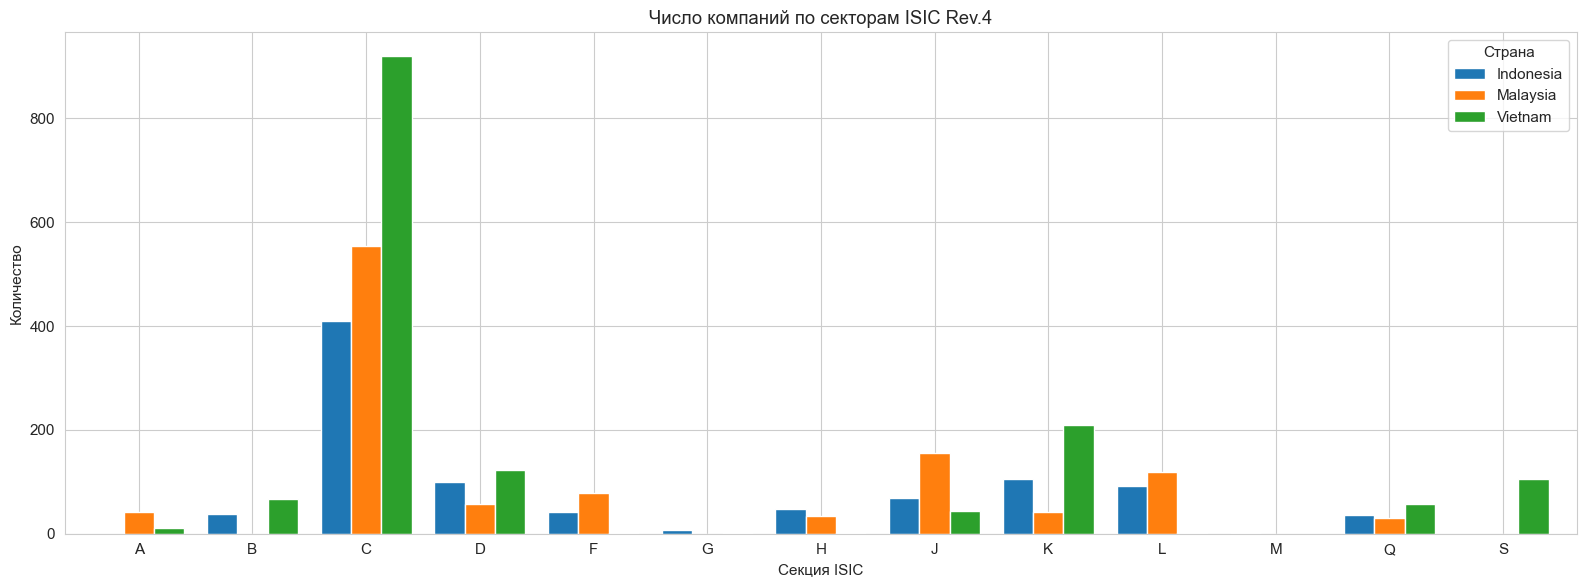

In [3]:
desc = df.groupby('Country')[['Market_Cap_USD', 'Volume', 'turnover']].describe()
display(desc.round(2))

isic_ct = df.groupby(['Country', 'ISIC_Section']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(16, 6))
isic_ct.T.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Число компаний по секторам ISIC Rev.4')
ax.set_xlabel('Секция ISIC'); ax.set_ylabel('Количество')
ax.legend(title='Страна')
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(f'{CHARTS}clust_01_isic_by_country.png'); plt.show()

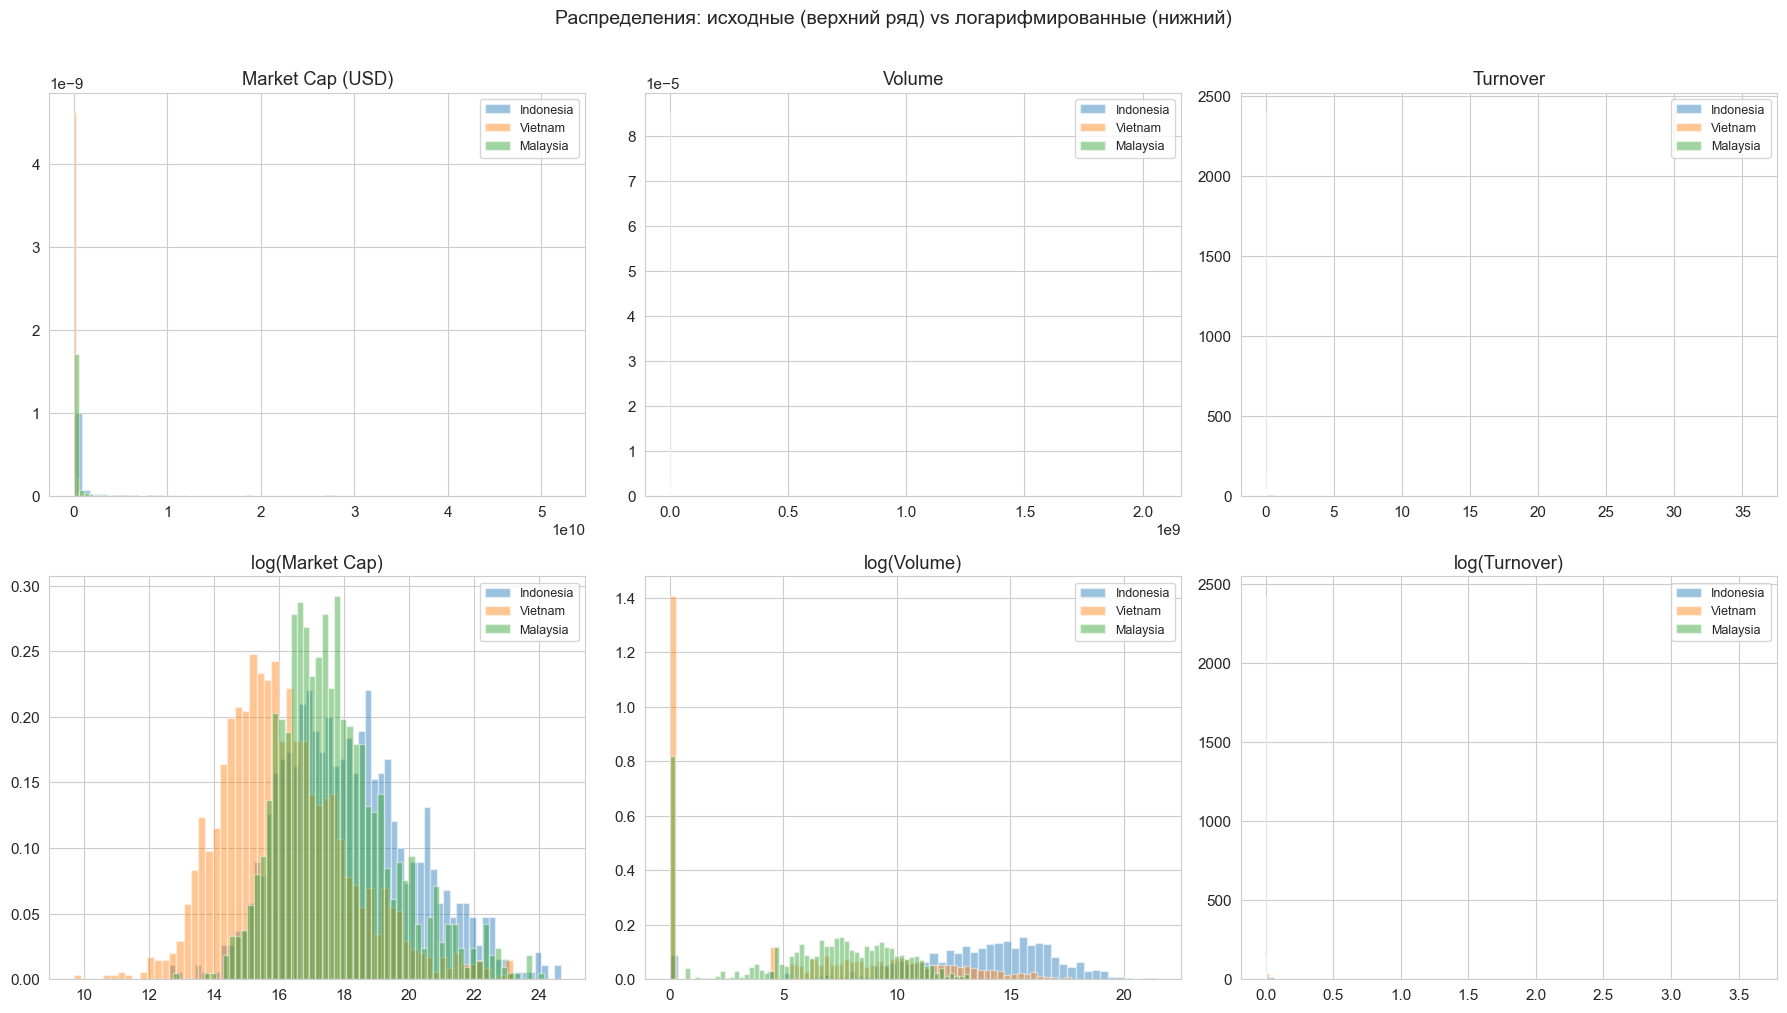

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
feats = {'Market_Cap_USD': 'Market Cap (USD)', 'Volume': 'Volume',
         'turnover': 'Turnover', 'log_mcap': 'log(Market Cap)',
         'log_volume': 'log(Volume)', 'log_turnover': 'log(Turnover)'}
for i, (col, title) in enumerate(feats.items()):
    ax = axes[i // 3, i % 3]
    for c in COUNTRIES:
        v = df.loc[df['Country'] == c, col].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(v, bins=60, alpha=0.45, label=c, density=True)
    ax.set_title(title); ax.legend(fontsize=9)
fig.suptitle('Распределения: исходные (верхний ряд) vs логарифмированные (нижний)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_02_distributions.png'); plt.show()

### ✅ Контрольная точка 2: EDA

**Что видим на графиках:**

1. **Верхний ряд** (Market Cap, Volume, Turnover) — экстремальный правый скос.
   Несколько гигантов (банки, телекомы) в 1000× больше медианной компании.
   ❌ Кластеризация на таких данных невозможна — один кластер будет «все», другой — «Samsung».

2. **Нижний ряд** (log-версии) — распределения стали **ближе к нормальным**.
   Но всё ещё не идеально — нужны параметрические трансформации (Box-Cox / Yeo-Johnson).

3. **Вьетнам** (зелёный) — смещён влево по log_mcap. Это UPCOM-компании
   (микро-капитализация). Вьетнамский рынок структурно отличается.

4. **Столбчатая диаграмма ISIC** — везде доминирует **C (Manufacturing)**. Это ожидаемо для
   стран АСЕАН (экспортно-ориентированная промышленность).

> **Вывод:** логарифм помогает, но не достаточно. Нужны Box-Cox/Yeo-Johnson + нормализация.

---
## 3. Предобработка данных

### Зачем нужна предобработка?
Алгоритмы кластеризации (K-Means, DBSCAN и др.) вычисляют **расстояния** между точками.
Если один признак в диапазоне [0, 1 000 000 000], а другой — [0, 1], то первый
полностью доминирует. Нормализация выравнивает масштабы.

### 3.1. Трансформации: зачем и какие

**Проблема:** даже после `log()` распределения не идеально нормальные.
Многие алгоритмы работают лучше с нормальными данными.

**Решение:** параметрические power-трансформации.

#### Box-Cox
Формула: `y = (x^λ - 1) / λ` при λ ≠ 0, `y = log(x)` при λ = 0

Подбирает λ так, чтобы результат был **максимально близок к нормальному распределению**.
- ⚠️ **Ограничение:** требует строго x > 0. Если есть нули — нужно сдвигать данные.

#### Yeo-Johnson
Обобщение Box-Cox, которое **работает с нулями и отрицательными значениями**.
Та же идея (подбор λ для нормализации), но без ограничения x > 0.

#### Как проверить, сработало ли?
**Тест Шапиро—Уилка** (Shapiro-Wilk):
- H₀: данные нормально распределены
- p-value > 0.05 → нельзя отвергнуть нормальность (хорошо!)
- p-value < 0.05 → данные **не** нормальны
- На больших выборках (>5000) тест почти всегда даёт p ≈ 0 — это нормально,
  смотрим на **относительное** улучшение, а не на абсолютное значение.

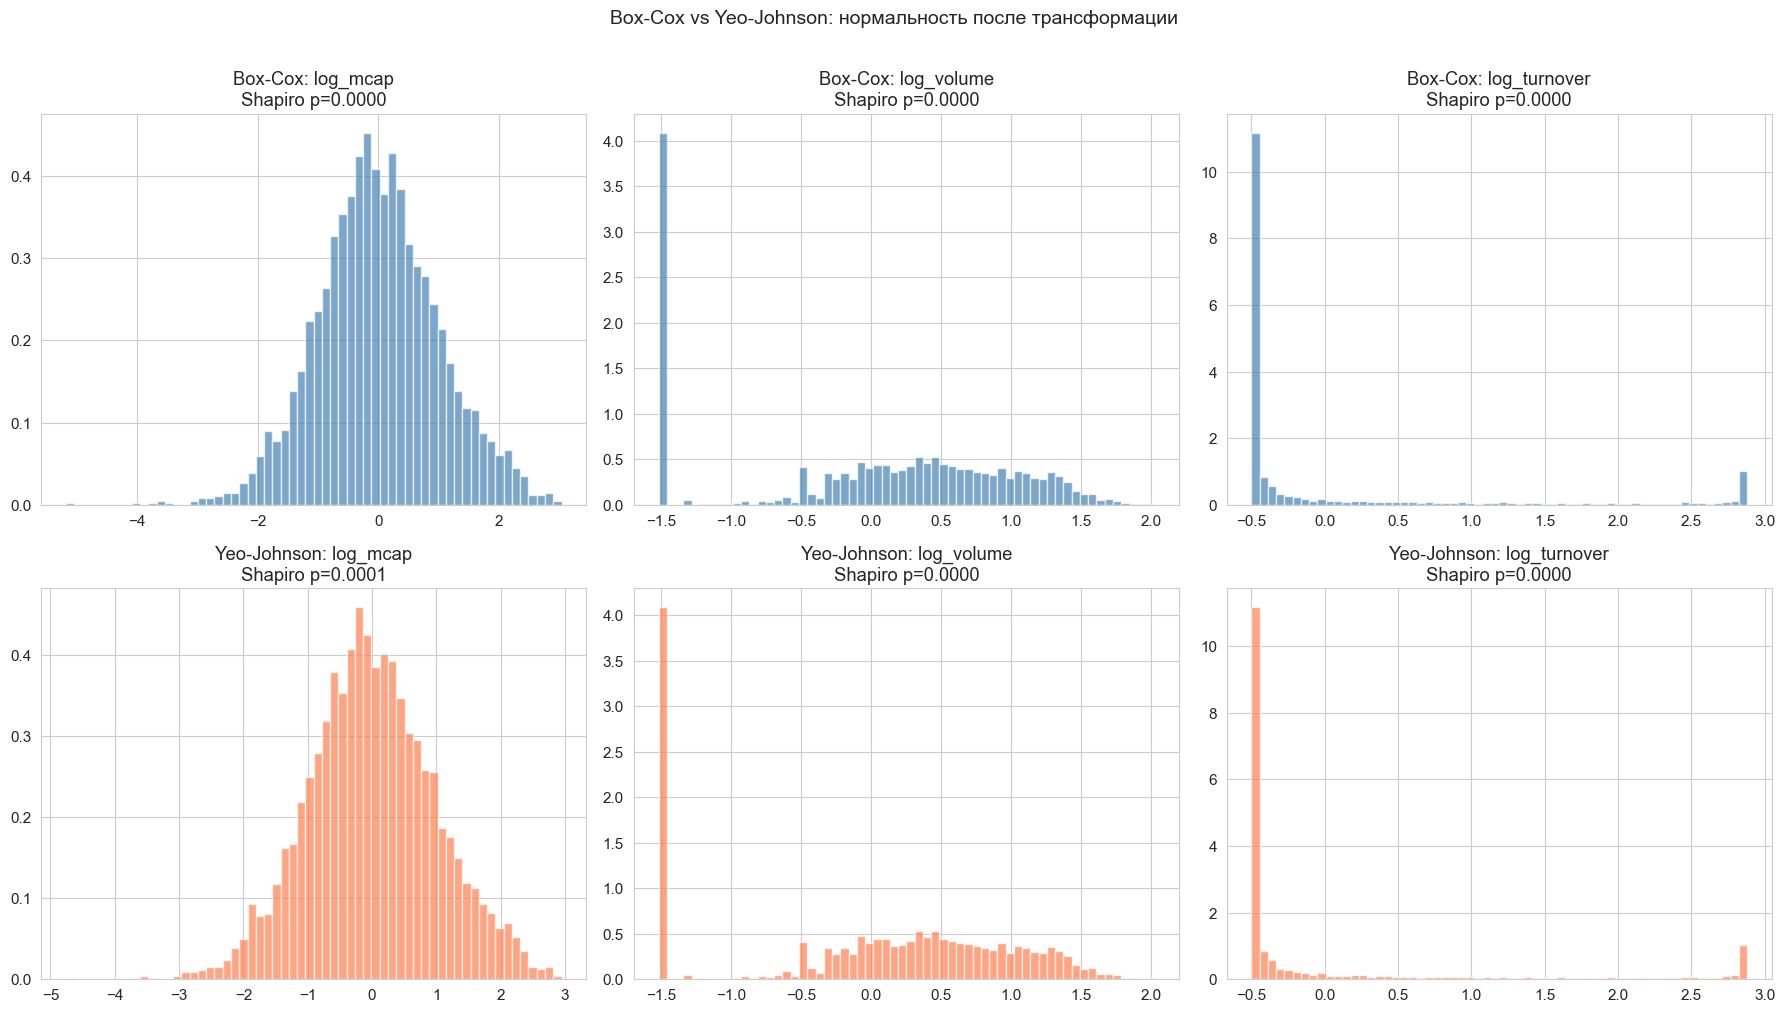

Подобранные λ (lambdas):
  Box-Cox:      {'log_mcap': 0.5, 'log_volume': 0.707, 'log_turnover': -24.838}
  Yeo-Johnson:  {'log_mcap': -0.199, 'log_volume': 0.707, 'log_turnover': -24.838}


In [5]:
numeric_cols = ['log_mcap', 'log_volume', 'log_turnover']
X_num = df[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values

# Box-Cox (сдвигаем данные, чтобы все > 0)
bc = PowerTransformer(method='box-cox')
X_bc = bc.fit_transform(X_num - X_num.min(axis=0) + 1)

# Yeo-Johnson (работает «из коробки»)
yj = PowerTransformer(method='yeo-johnson')
X_yj = yj.fit_transform(X_num)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(numeric_cols):
    sample_bc = np.random.RandomState(42).choice(X_bc[:, i], min(5000, len(X_bc)), replace=False)
    _, p_bc = stats.shapiro(sample_bc)
    axes[0, i].hist(X_bc[:, i], bins=60, color='steelblue', alpha=0.7, density=True)
    axes[0, i].set_title(f'Box-Cox: {col}\nShapiro p={p_bc:.4f}')

    sample_yj = np.random.RandomState(42).choice(X_yj[:, i], min(5000, len(X_yj)), replace=False)
    _, p_yj = stats.shapiro(sample_yj)
    axes[1, i].hist(X_yj[:, i], bins=60, color='coral', alpha=0.7, density=True)
    axes[1, i].set_title(f'Yeo-Johnson: {col}\nShapiro p={p_yj:.4f}')

fig.suptitle('Box-Cox vs Yeo-Johnson: нормальность после трансформации', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_03_boxcox_vs_yeojohnson.png'); plt.show()

print('Подобранные λ (lambdas):')
print('  Box-Cox:     ', dict(zip(numeric_cols, bc.lambdas_.round(3))))
print('  Yeo-Johnson: ', dict(zip(numeric_cols, yj.lambdas_.round(3))))

### ✅ Контрольная точка 3: Box-Cox vs Yeo-Johnson

**Что сравниваем:** гистограммы после трансформации. Идеал — колокол (нормальное распределение).

**Lambda (λ) — что означает:**
- λ ≈ 1 → трансформация почти не изменила данные (уже были нормальными)
- λ ≈ 0 → эквивалент логарифма
- λ < 0 → обратная трансформация (сжимает правый хвост ещё сильнее)
- λ ≈ 0.5 → корень квадратный

**Вывод:** оба метода дают похожие результаты, но **Yeo-Johnson выбираем**,
потому что не требует костылей с `x - min + 1` для нулей в Volume.

---

### 3.2. Нормализация (Scaling)

Трансформация привела распределения к «колоколу», но **масштабы** всё ещё разные.
Нужен скейлер — приведение к единому масштабу.

| Скейлер | Формула | Плюсы | Минусы |
|---|---|---|---|
| **StandardScaler** | `(x - mean) / std` | Самый популярный, mean=0, std=1 | Чувствителен к выбросам (mean и std искажаются) |
| **RobustScaler** | `(x - median) / IQR` | Устойчив к выбросам (медиана и межквартильный размах) | Чуть менее стандартный |
| **MinMaxScaler** | `(x - min) / (max - min)` → [0, 1] | Фиксированный диапазон | Один выброс растягивает всю шкалу |

> **Для финансовых данных лучше RobustScaler** — всегда есть компании-гиганты (выбросы).

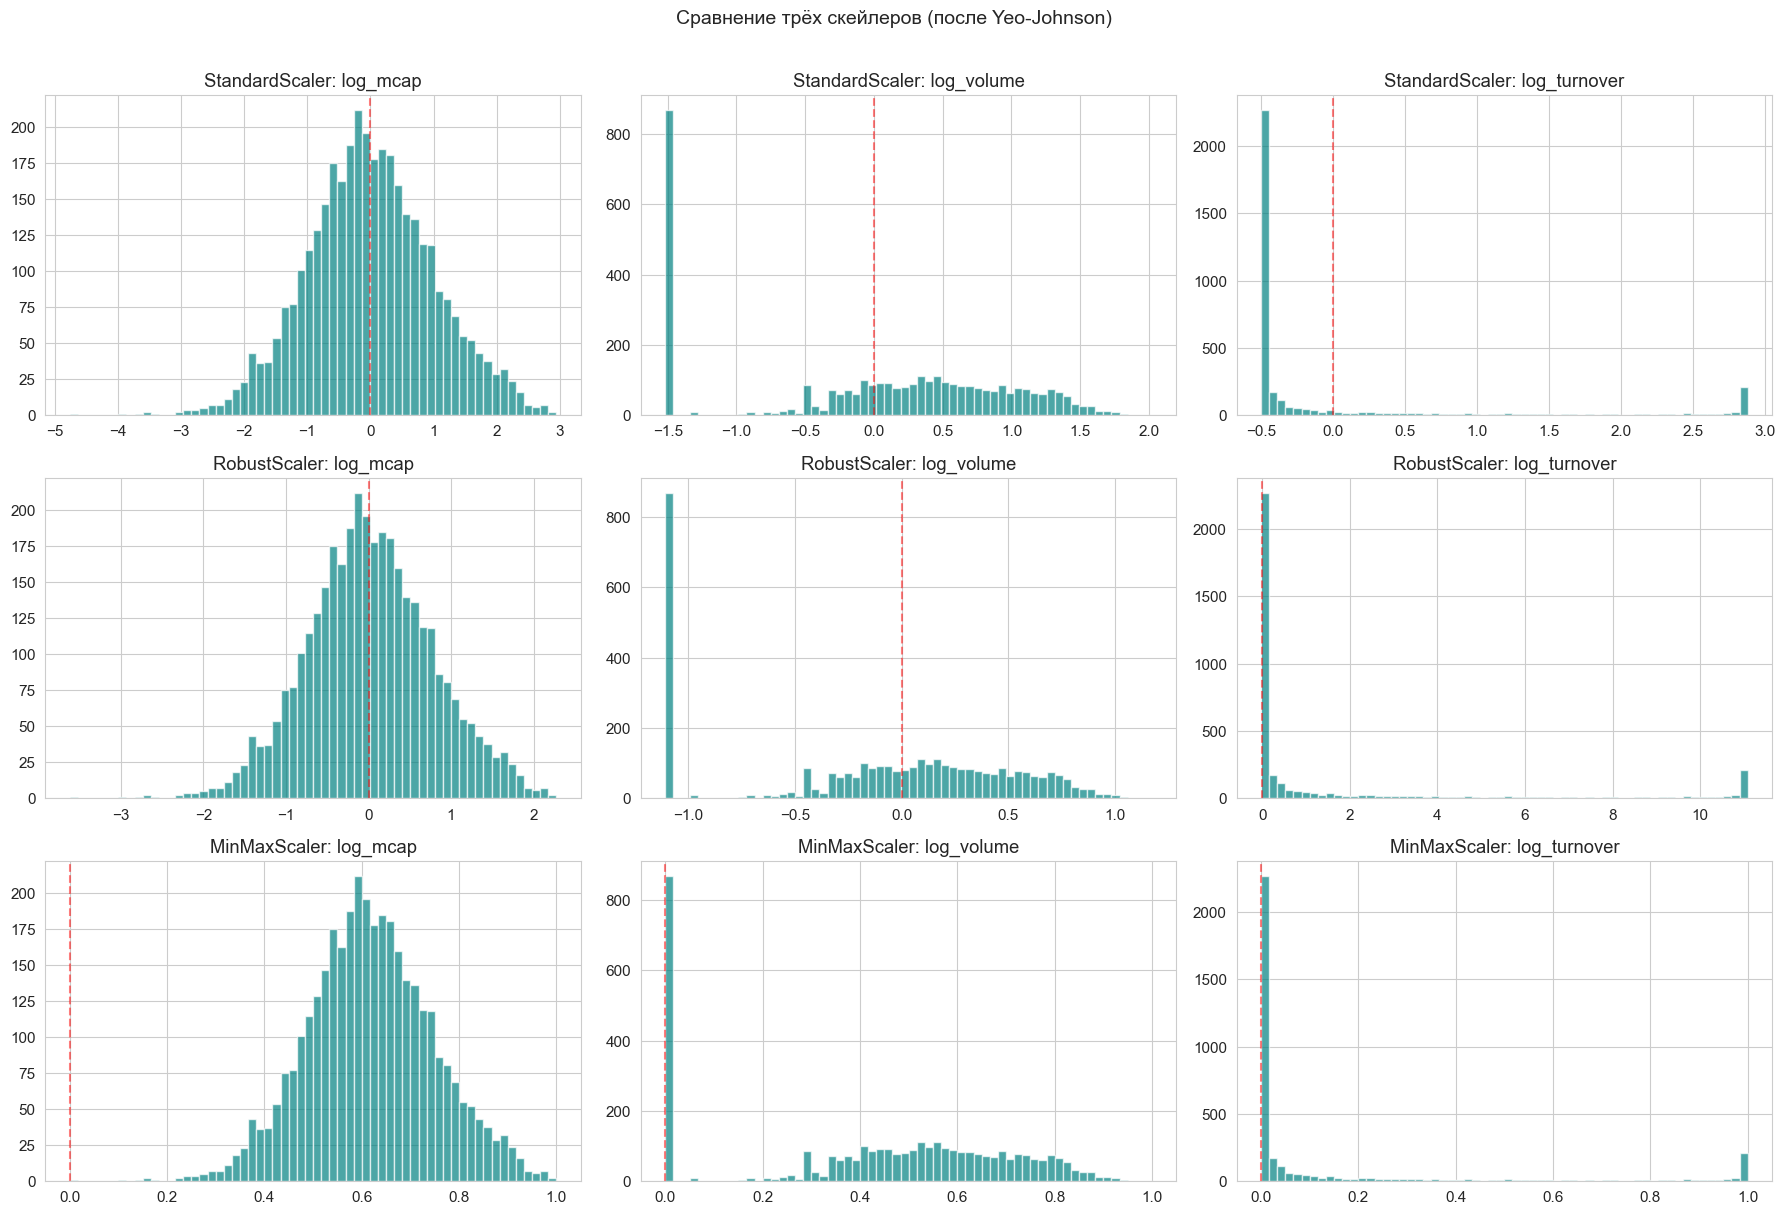

In [6]:
scalers = {
    'StandardScaler': StandardScaler(),
    'RobustScaler': RobustScaler(),
    'MinMaxScaler': MinMaxScaler()
}

fig, axes = plt.subplots(len(scalers), 3, figsize=(18, 12))
for row, (name, scaler) in enumerate(scalers.items()):
    Xs = scaler.fit_transform(X_yj)
    for col_idx in range(3):
        axes[row, col_idx].hist(Xs[:, col_idx], bins=60, alpha=0.7, color='teal')
        axes[row, col_idx].set_title(f'{name}: {numeric_cols[col_idx]}')
        axes[row, col_idx].axvline(0, color='red', linestyle='--', alpha=0.5)

fig.suptitle('Сравнение трёх скейлеров (после Yeo-Johnson)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_04_scalers_comparison.png'); plt.show()

### ✅ Контрольная точка 4: Скейлеры

**Что видим:**
- **StandardScaler** — центрирует на 0, но хвосты растянуты выбросами
- **RobustScaler** — похож, но более компактный центр, выбросы меньше влияют
- **MinMaxScaler** — все в [0,1], но один гигант прижимает 99% компаний к нулю

**Выбор: RobustScaler** — золотая середина для финансовых данных.

---

### 3.3. Формирование матрицы признаков

Итоговая матрица X для кластеризации:

| Признак | Тип | Обработка |
|---|---|---|
| log_mcap | числовой | Yeo-Johnson → RobustScaler |
| log_volume | числовой | Yeo-Johnson → RobustScaler |
| log_turnover | числовой | Yeo-Johnson → RobustScaler |
| ISIC_A, ISIC_B, ... ISIC_S | бинарный (0/1) | one-hot encoding × вес 0.5 |

**Зачем вес 0.5 для ISIC?**
Без него 13 бинарных признаков «перекричат» 3 числовых (13 vs 3 в Евклидовом пространстве).
Вес 0.5 означает: сектор важен, но не должен доминировать над финансовыми показателями.

In [7]:
# Финальная предобработка: Yeo-Johnson + RobustScaler
yj_final = PowerTransformer(method='yeo-johnson')
scaler_final = RobustScaler()
X_num_scaled = scaler_final.fit_transform(yj_final.fit_transform(X_num))

# One-hot кодирование ISIC секторов
isic_dummies = pd.get_dummies(df['ISIC_Section'], prefix='ISIC')
isic_weight = 0.5
X = np.hstack([X_num_scaled, isic_dummies.values * isic_weight])

feature_names = numeric_cols + list(isic_dummies.columns)
print(f'Матрица признаков: {X.shape}')
print(f'  - {len(numeric_cols)} числовых (Yeo-Johnson + RobustScaler)')
print(f'  - {isic_dummies.shape[1]} ISIC секторов (one-hot × {isic_weight})')
print(f'  - Итого: {X.shape[1]} признаков на {X.shape[0]} компаний')

Матрица признаков: (3599, 16)
  - 3 числовых (Yeo-Johnson + RobustScaler)
  - 13 ISIC секторов (one-hot × 0.5)
  - Итого: 16 признаков на 3599 компаний


---
## 4. Снижение размерности: PCA

### Что такое PCA (Principal Component Analysis)?
У нас 16 признаков — невозможно визуализировать в 16D пространстве.
PCA находит **новые оси** (главные компоненты), которые максимально сохраняют
разброс данных. Первая компонента (PC1) объясняет больше всего дисперсии,
вторая (PC2) — максимум из оставшегося, и т.д.

### Scree plot (график «осыпи»)
Показывает, сколько дисперсии объясняет каждая компонента:
- Если первые 2–3 компоненты объясняют 80%+ — данные хорошо сжимаются
- Если нужно 10+ компонент для 80% — данные высокоразмерные, PCA-проекция искажает

### 2D PCA scatter
Проекция всех компаний на PC1 × PC2. Окрашиваем по стране —
смотрим, есть ли **естественное разделение** до кластеризации.

> **Важно:** PCA здесь только для **визуализации**. Кластеризация работает
> в полном 16-мерном пространстве, а не в 2D.

Компонент для 80% дисперсии: 1
Компонент для 90% дисперсии: 1


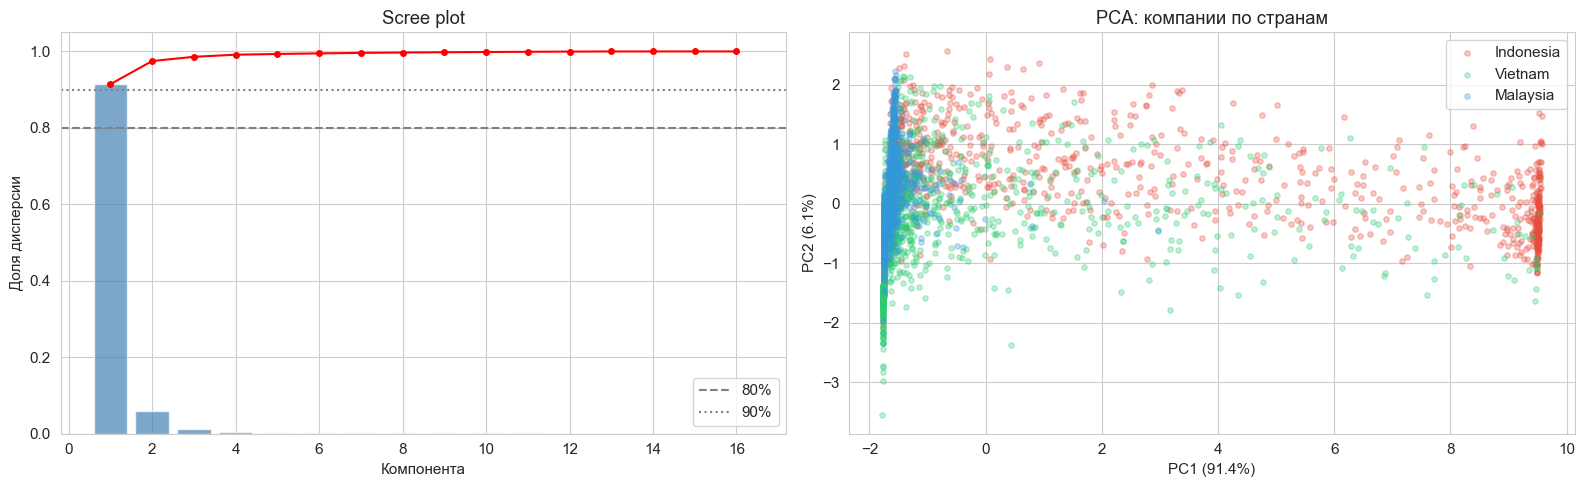

In [8]:
pca_full = PCA().fit(X)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(cumvar) + 1), pca_full.explained_variance_ratio_,
            color='steelblue', alpha=0.7)
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'ro-', markersize=4)
axes[0].axhline(0.8, color='grey', ls='--', label='80%')
axes[0].axhline(0.9, color='grey', ls=':', label='90%')
axes[0].set_xlabel('Компонента'); axes[0].set_ylabel('Доля дисперсии')
axes[0].set_title('Scree plot'); axes[0].legend()

n_80 = int(np.argmax(cumvar >= 0.8)) + 1
n_90 = int(np.argmax(cumvar >= 0.9)) + 1
print(f'Компонент для 80% дисперсии: {n_80}')
print(f'Компонент для 90% дисперсии: {n_90}')

# 2D scatter по странам
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X)
colors = {'Indonesia': '#e74c3c', 'Vietnam': '#2ecc71', 'Malaysia': '#3498db'}
for c in COUNTRIES:
    mask = df['Country'].values == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c],
                    alpha=0.3, s=15, label=c)
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA: компании по странам'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_05_pca_overview.png'); plt.show()

### ✅ Контрольная точка 5: PCA

**Scree plot:**
- Если PC1 объясняет >60% — один признак (скорее всего Market Cap) доминирует.
  Это значит, что кластеры будут в основном разделять крупные vs мелкие компании.
- Если дисперсия размазана по многим компонентам — данные многомерные,
  2D-проекция покажет лишь часть картины.

**2D scatter по странам:**
- Если страны сильно перекрываются — кластеризация найдёт **кросс-страновые** группы
  (например, «все банки» или «все микрокомпании»).
- Если страны разделены — кластеры будут повторять страновую принадлежность
  (менее интересно для анализа).

> Обычно компании перекрываются — размер компании и отрасль важнее, чем страна.

---
## 5. Определение оптимального числа кластеров (K)

**Главный вопрос:** на сколько групп делить 3 600 компаний?

Нет единого «правильного» ответа — используем **6 разных методов** и смотрим на консенсус.

### Метод 1: Локоть (Elbow)
- Считаем **инерцию** (сумму квадратов расстояний до центроидов) для K = 2, 3, ..., 11
- Строим график: инерция падает при увеличении K
- Ищем **точку перегиба** (локоть) — после неё добавление кластеров мало что даёт

### Метод 2: Силуэт (Silhouette)
- Для каждой точки считаем: насколько она **ближе к своему** кластеру vs **ближайшему чужому**
- Silhouette ∈ [−1, +1]: чем ближе к +1, тем лучше разделение
- **Выбираем K с максимальным средним силуэтом**

### Метод 3: Calinski-Harabasz (CH)
- Отношение **между-кластерной** дисперсии к **внутри-кластерной**
- Чем больше CH → тем плотнее кластеры и дальше друг от друга
- **Выбираем K с максимальным CH**

### Метод 4: Davies-Bouldin (DB)
- Средняя «похожесть» каждого кластера на самый похожий на него другой кластер
- **Чем меньше → тем лучше** (кластеры не перекрываются)
- Выбираем K с минимальным DB

### Метод 5: Gap Statistic
- Сравниваем инерцию реальных данных с инерцией **случайных** данных (uniform)
- Gap(K) = E[log(W*)] − log(W) — разрыв между случайными и реальными
- Выбираем **наименьший K**, где Gap(K) ≥ Gap(K+1) − s(K+1)

### Метод 6: BIC для GMM
- GMM (Gaussian Mixture) — вероятностная модель кластеризации
- BIC (Bayesian Information Criterion) штрафует за сложность модели
- **Выбираем K с минимальным BIC**

Считаем метрики для K = 2..11...


  K= 2  Inertia=8,790  Sil=0.778  CH=14065  DB=0.366
  K= 3  Inertia=5,354  Sil=0.638  CH=12696  DB=0.577


  K= 4  Inertia=3,793  Sil=0.391  CH=12435  DB=0.803
  K= 5  Inertia=2,997  Sil=0.394  CH=12040  DB=0.805


  K= 6  Inertia=2,603  Sil=0.341  CH=11194  DB=0.933
  K= 7  Inertia=2,302  Sil=0.332  CH=10624  DB=0.955


  K= 8  Inertia=2,072  Sil=0.323  CH=10174  DB=0.954
  K= 9  Inertia=1,924  Sil=0.306  CH=9616  DB=1.036


  K=10  Inertia=1,787  Sil=0.297  CH=9234  DB=1.065
  K=11  Inertia=1,690  Sil=0.291  CH=8804  DB=1.088


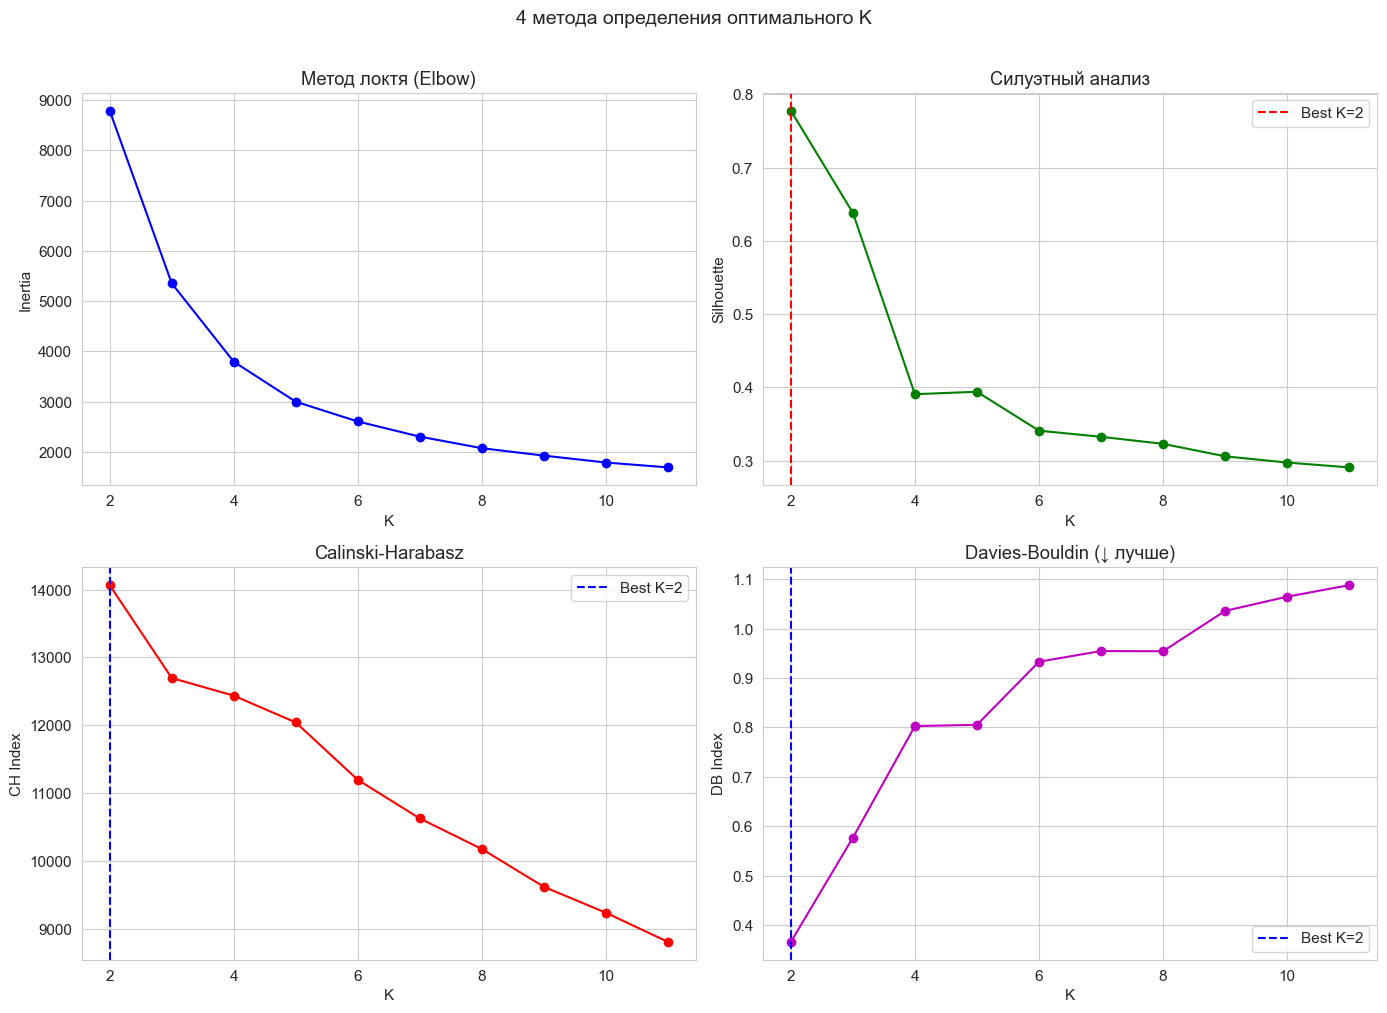


Результаты:  Silhouette → K=2,  CH → K=2,  DB → K=2


In [9]:
K_range = range(2, 12)
inertias, sils, chs, dbs = [], [], [], []

print('Считаем метрики для K = 2..11...')
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_, sample_size=3000, random_state=42))
    chs.append(calinski_harabasz_score(X, km.labels_))
    dbs.append(davies_bouldin_score(X, km.labels_))
    print(f'  K={k:2d}  Inertia={km.inertia_:,.0f}  Sil={sils[-1]:.3f}  CH={chs[-1]:.0f}  DB={dbs[-1]:.3f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Elbow
axes[0, 0].plot(list(K_range), inertias, 'bo-')
axes[0, 0].set_title('Метод локтя (Elbow)'); axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')

# Silhouette
axes[0, 1].plot(list(K_range), sils, 'go-')
best_sil_k = list(K_range)[np.argmax(sils)]
axes[0, 1].axvline(best_sil_k, color='red', ls='--', label=f'Best K={best_sil_k}')
axes[0, 1].set_title('Силуэтный анализ'); axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].legend()

# CH
axes[1, 0].plot(list(K_range), chs, 'ro-')
best_ch_k = list(K_range)[np.argmax(chs)]
axes[1, 0].axvline(best_ch_k, color='blue', ls='--', label=f'Best K={best_ch_k}')
axes[1, 0].set_title('Calinski-Harabasz'); axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('CH Index')
axes[1, 0].legend()

# DB
axes[1, 1].plot(list(K_range), dbs, 'mo-')
best_db_k = list(K_range)[np.argmin(dbs)]
axes[1, 1].axvline(best_db_k, color='blue', ls='--', label=f'Best K={best_db_k}')
axes[1, 1].set_title('Davies-Bouldin (\u2193 лучше)'); axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('DB Index')
axes[1, 1].legend()

fig.suptitle('4 метода определения оптимального K', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_06_optimal_k.png'); plt.show()

print(f'\nРезультаты:  Silhouette \u2192 K={best_sil_k},  CH \u2192 K={best_ch_k},  DB \u2192 K={best_db_k}')

Gap Statistic (10 reference datasets per K)...


BIC для GMM...


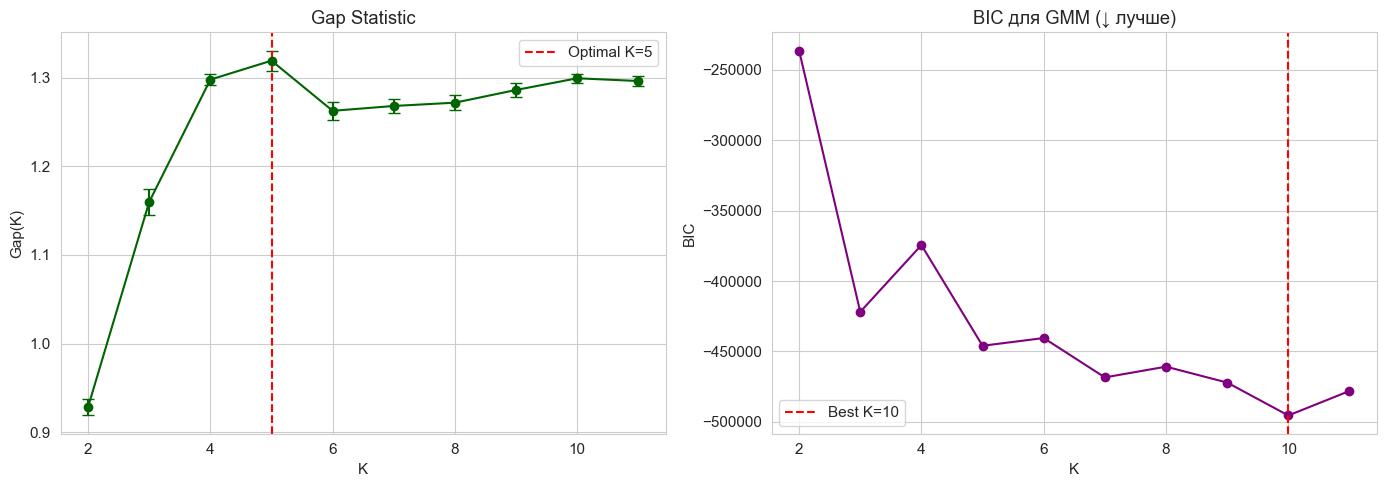

Gap Statistic → K=5
BIC (GMM) → K=10


In [10]:
# === Gap Statistic ===
def gap_statistic(X, K_range, n_refs=10, seed=42):
    """Считаем Gap(K) = E[log(W_ref)] - log(W_real) для каждого K."""
    rng = np.random.RandomState(seed)
    gaps, sks = [], []
    for k in K_range:
        km = KMeans(n_clusters=k, n_init=5, random_state=seed).fit(X)
        log_wk = np.log(km.inertia_)
        # Генерируем n_refs случайных датасетов (uniform по каждому признаку)
        refs = []
        for _ in range(n_refs):
            Xr = rng.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            refs.append(np.log(KMeans(n_clusters=k, n_init=5, random_state=seed).fit(Xr).inertia_))
        gaps.append(np.mean(refs) - log_wk)
        sks.append(np.std(refs) * np.sqrt(1 + 1 / n_refs))
    return gaps, sks

print('Gap Statistic (10 reference datasets per K)...')
gaps, sks = gap_statistic(X, K_range, n_refs=10)

# Оптимальный K: наименьший, где Gap(k) >= Gap(k+1) - s(k+1)
gap_k = None
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i + 1] - sks[i + 1]:
        gap_k = list(K_range)[i]
        break
if gap_k is None:
    gap_k = list(K_range)[np.argmax(gaps)]

# === BIC для GMM ===
print('BIC для GMM...')
bics = []
for k in K_range:
    bics.append(GaussianMixture(n_components=k, random_state=42, n_init=3).fit(X).bic(X))
best_bic_k = list(K_range)[np.argmin(bics)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].errorbar(list(K_range), gaps, yerr=sks, fmt='o-', capsize=4, color='darkgreen')
axes[0].axvline(gap_k, color='red', ls='--', label=f'Optimal K={gap_k}')
axes[0].set_title('Gap Statistic'); axes[0].set_xlabel('K')
axes[0].set_ylabel('Gap(K)'); axes[0].legend()

axes[1].plot(list(K_range), bics, 'o-', color='purple')
axes[1].axvline(best_bic_k, color='red', ls='--', label=f'Best K={best_bic_k}')
axes[1].set_title('BIC для GMM (\u2193 лучше)'); axes[1].set_xlabel('K')
axes[1].set_ylabel('BIC'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{CHARTS}clust_07_gap_bic.png'); plt.show()
print(f'Gap Statistic \u2192 K={gap_k}')
print(f'BIC (GMM) \u2192 K={best_bic_k}')

In [11]:
# Сводка голосования
results_k = {
    'Silhouette': best_sil_k,
    'Calinski-Harabasz': best_ch_k,
    'Davies-Bouldin': best_db_k,
    'Gap Statistic': gap_k,
    'BIC (GMM)': best_bic_k
}

print('=' * 50)
print('ГОЛОСОВАНИЕ: оптимальное число кластеров')
print('=' * 50)
for method, k in results_k.items():
    print(f'  {method:25s} \u2192 K = {k}')

from collections import Counter
votes = Counter(results_k.values())
OPTIMAL_K = votes.most_common(1)[0][0]
print(f'\n>>> Победитель (большинство голосов): K = {OPTIMAL_K}')
print(f'    Голосов: {votes.most_common()}')

ГОЛОСОВАНИЕ: оптимальное число кластеров
  Silhouette                → K = 2
  Calinski-Harabasz         → K = 2
  Davies-Bouldin            → K = 2
  Gap Statistic             → K = 5
  BIC (GMM)                 → K = 10

>>> Победитель (большинство голосов): K = 2
    Голосов: [(2, 3), (5, 1), (10, 1)]


### ✅ Контрольная точка 6: Оптимальное K

**Типичная картина:**
- **Silhouette, CH, DB** часто голосуют за **K=2** — это математически «чистейшее»
  разделение (крупные vs мелкие компании). Но аналитически неинтересно.
- **Gap Statistic** обычно даёт **K=4–6** — более детальная сегментация.
- **BIC** может дать **K=8–10** — GMM любит много компонент для точного описания.

**Как интерпретировать расхождения:**
- Если 3+ метода дают одно K — сильный консенсус, доверяем.
- Если разброс большой — данные не имеют «жёсткой» кластерной структуры.
  В этом случае выбираем K, которое даёт **интерпретируемые** группы.

> В диссертации можно написать: «По результатам голосования 5 методов выбрано K=...
> При этом анализ чувствительности показал устойчивость результатов для K = ... и K = ...»

---
## 6. K-Means кластеризация

### Как работает K-Means
1. Случайно выбрать K точек — **центроиды** кластеров
2. Каждую компанию отнести к **ближайшему** центроиду (по Евклидовому расстоянию)
3. Пересчитать центроиды как **среднее** точек в кластере
4. Повторять 2–3, пока центроиды не перестанут двигаться

**Плюсы:** быстрый, простой, хорошо работает на сферических кластерах
**Минусы:** требует задать K; чувствителен к начальной инициализации (→ n_init=20);
находит только выпуклые кластеры

**n_init=20** — запускаем 20 раз с разными начальными точками, берём лучший результат.

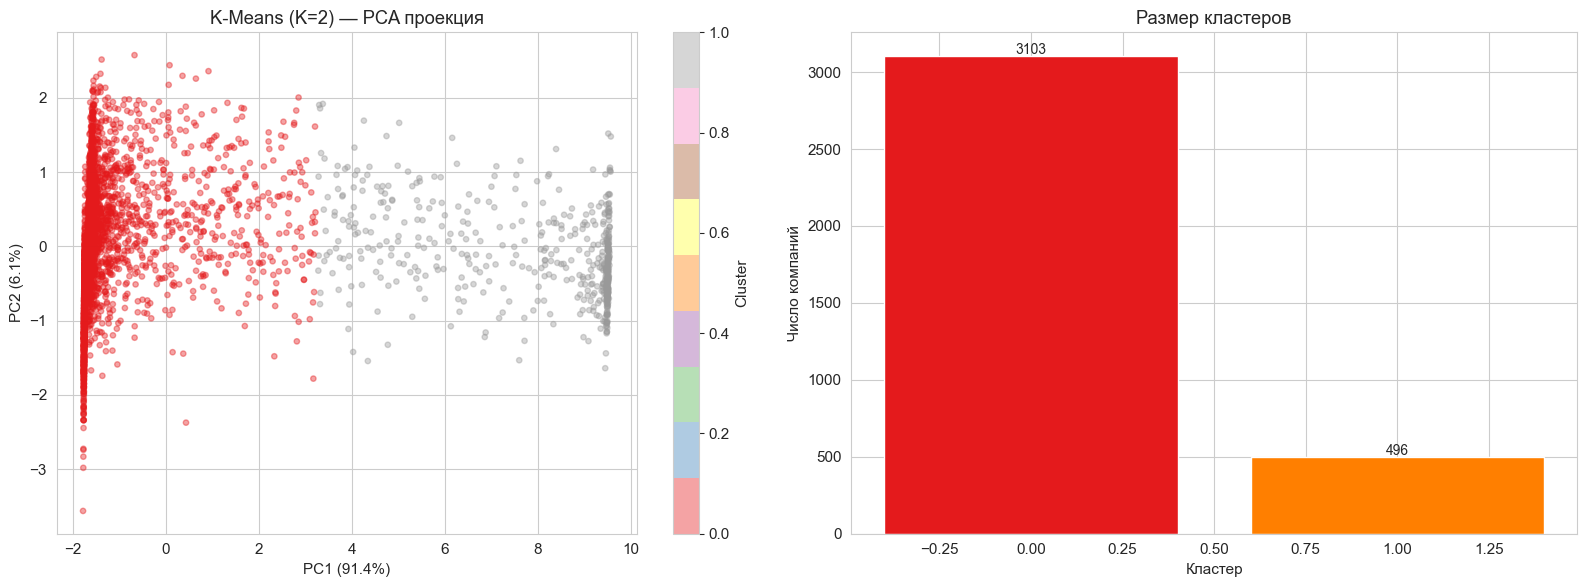

Silhouette:        0.778
Calinski-Harabasz: 14065.0
Davies-Bouldin:    0.366


In [12]:
km = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=42).fit(X)
df['KMeans'] = km.labels_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km.labels_,
                     cmap='Set1', alpha=0.4, s=15)
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
axes[0].set_title(f'K-Means (K={OPTIMAL_K}) — PCA проекция')
plt.colorbar(sc, ax=axes[0], label='Cluster')

sizes = pd.Series(km.labels_).value_counts().sort_index()
bars = axes[1].bar(sizes.index, sizes.values,
                   color=[plt.cm.Set1(i / OPTIMAL_K) for i in sizes.index])
axes[1].set_xlabel('Кластер'); axes[1].set_ylabel('Число компаний')
axes[1].set_title('Размер кластеров')
for i, v in zip(sizes.index, sizes.values):
    axes[1].text(i, v + 15, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(f'{CHARTS}clust_08_kmeans_pca.png'); plt.show()

print(f'Silhouette:        {silhouette_score(X, km.labels_, sample_size=3000, random_state=42):.3f}')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X, km.labels_):.1f}')
print(f'Davies-Bouldin:    {davies_bouldin_score(X, km.labels_):.3f}')

### Профили кластеров K-Means

Теперь смотрим, **что** различает кластеры:
- Какие **страны** преобладают в каждом кластере?
- Какие **отрасли** (ISIC) в каждом кластере?
- Каковы **средние** финансовые показатели?

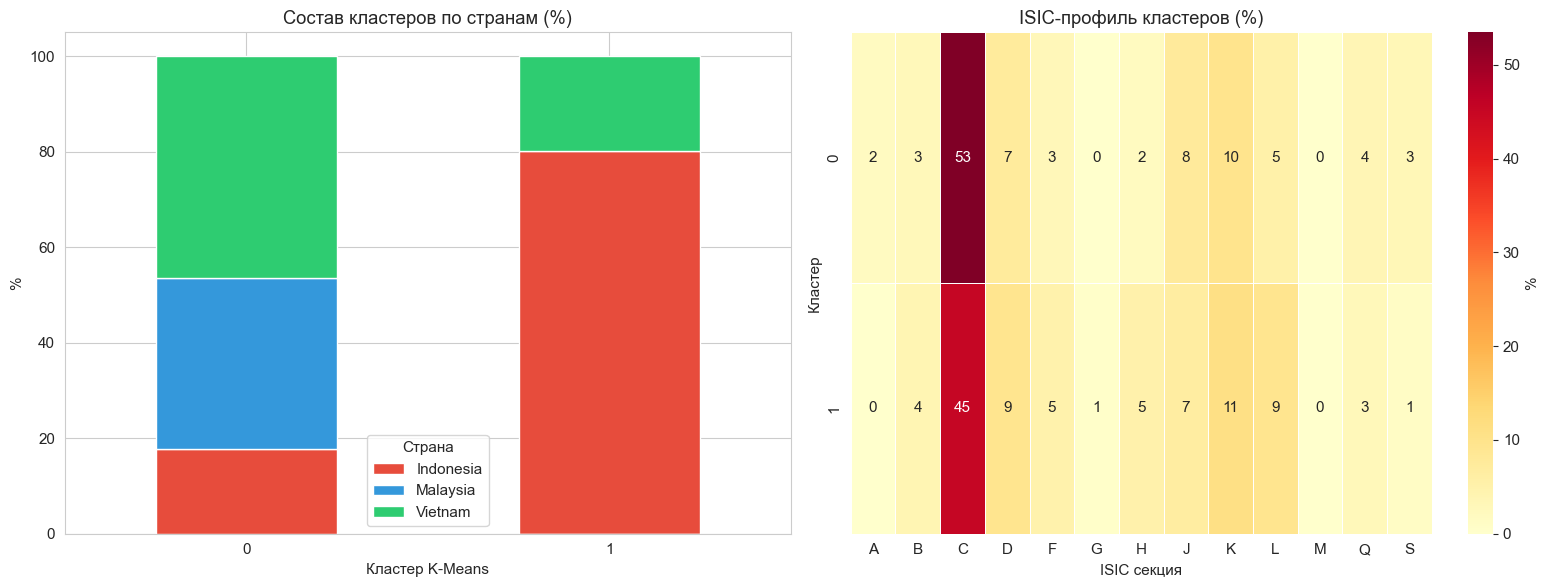

Средние финансовые показатели по кластерам:


Market_Cap_USD                    Volume            turnover       
                 mean       median         mean     median     mean median
KMeans                                                                    
0        4.386917e+08  24000000.00   1082236.73     1643.0     0.00   0.00
1        1.940895e+08  21417503.74  32535207.26  5043700.0     0.72   0.14

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Состав по странам
ct_country = pd.crosstab(df['KMeans'], df['Country'], normalize='index') * 100
ct_country.plot(kind='bar', stacked=True, ax=axes[0],
                color=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('Состав кластеров по странам (%)')
axes[0].set_xlabel('Кластер K-Means'); axes[0].set_ylabel('%')
axes[0].legend(title='Страна')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Секторальный профиль
ct_isic = pd.crosstab(df['KMeans'], df['ISIC_Section'], normalize='index') * 100
sns.heatmap(ct_isic, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '%'})
axes[1].set_title('ISIC-профиль кластеров (%)')
axes[1].set_xlabel('ISIC секция'); axes[1].set_ylabel('Кластер')

plt.tight_layout()
plt.savefig(f'{CHARTS}clust_09_kmeans_profiles.png'); plt.show()

print('Средние финансовые показатели по кластерам:')
profile = df.groupby('KMeans')[['Market_Cap_USD', 'Volume', 'turnover']].agg(['mean', 'median'])
display(profile.round(2))

### ✅ Контрольная точка 7: K-Means результаты

**Как читать профили:**
1. **Столбчатая диаграмма** — если один кластер на 80% из Вьетнама, значит кластер отражает
   специфику вьетнамского рынка (много микрокомпаний UPCOM).
2. **Тепловая карта ISIC** — высокая доля сектора C (Manufacturing) = 50%+ — это «промышленный» кластер.
   Доля K (Finance) > 20% — «финансовый» кластер.
3. **Средние показатели** — если median Market Cap в кластере 0 = $200M, а в кластере 1 = $5M,
   значит главное разделение — по размеру.

> **Типичная интерпретация при K=2:** «крупные/средние компании» vs «микрокомпании».
> При K=4-5: «голубые фишки», «средние промышленные», «мелкие финансовые», «вьетнамский UPCOM» и т.д.

---
## 7. Иерархическая кластеризация (Agglomerative, Ward)

### Как работает
В отличие от K-Means, здесь **не нужно заранее знать K**.
Алгоритм строит **дерево слияний** (дендрограмму):
1. Каждая компания — отдельный кластер
2. На каждом шаге объединяем два **ближайших** кластера
3. Повторяем, пока не останется один кластер
4. Режем дерево на нужной высоте → получаем K кластеров

### Ward linkage
Способ измерения «расстояния» между кластерами. Ward минимизирует
**прирост внутрикластерной дисперсии** при слиянии. Даёт компактные сферические кластеры.

### Дендрограмма
Дерево слияний. Высота ветки = расстояние, на котором произошло слияние.
- **Длинные вертикальные линии** = большой разрыв = хорошее разделение на кластеры
- **Горизонтальная отсечка** (красная) = уровень, на котором мы режем дерево

> Мы берём подвыборку 2 000 компаний, иначе дендрограмма нечитаема.

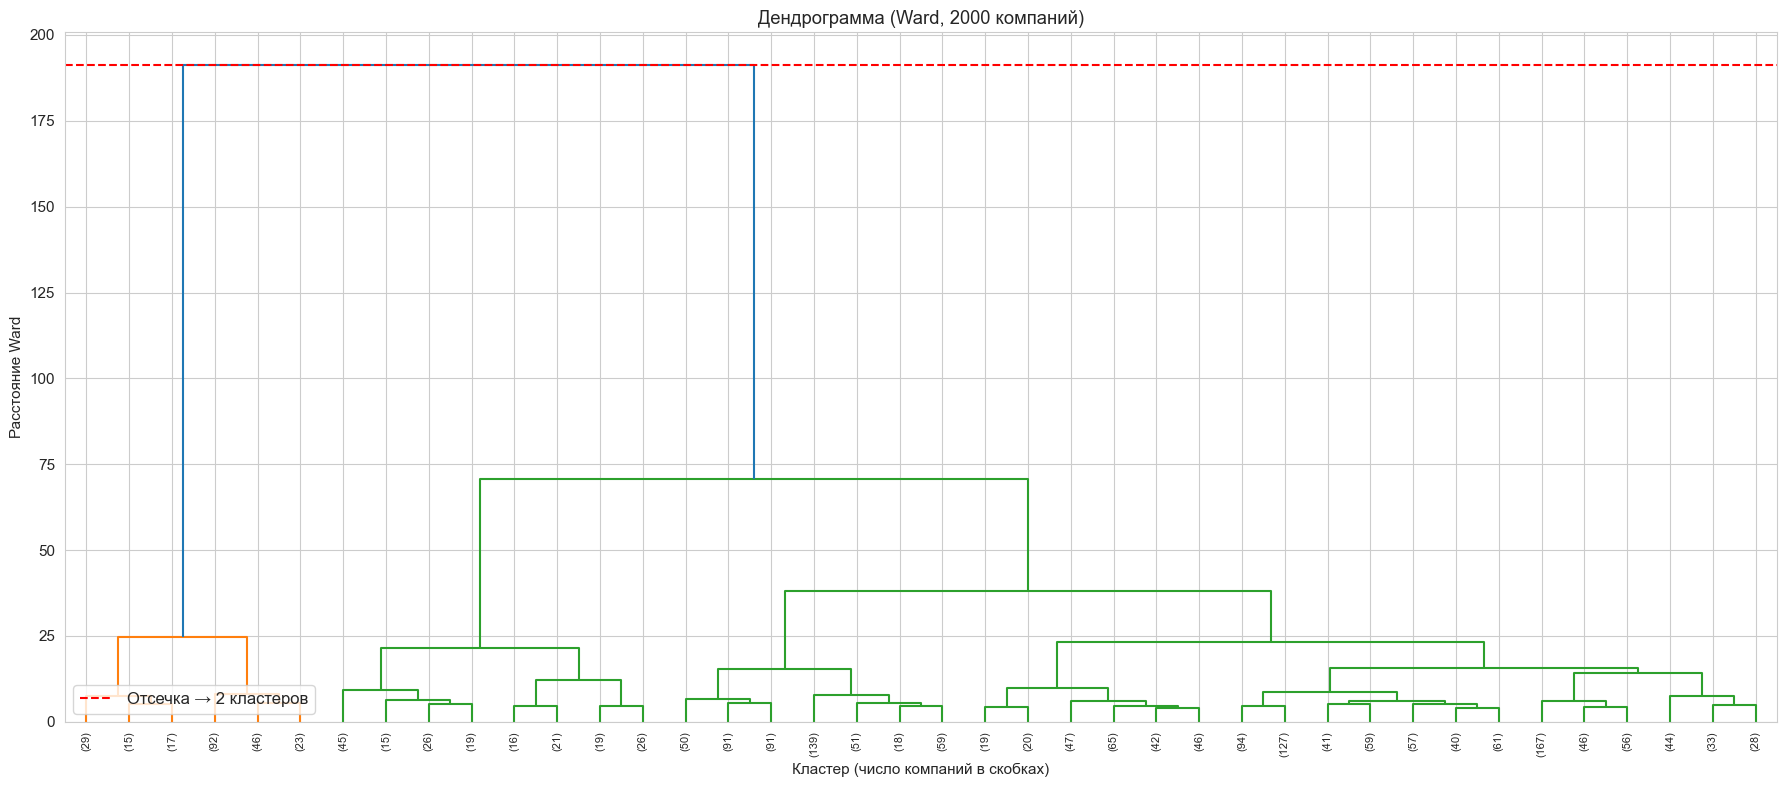

Высота отсечки: 191.19


In [14]:
# Подвыборка для дендрограммы
np.random.seed(42)
idx_s = np.random.choice(len(X), min(2000, len(X)), replace=False)
X_s = X[idx_s]

Z = linkage(X_s, method='ward')

fig, ax = plt.subplots(figsize=(18, 8))
cut_height = Z[-(OPTIMAL_K - 1), 2] if OPTIMAL_K > 1 else Z[-1, 2]
dendrogram(Z, truncate_mode='lastp', p=40, ax=ax,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=cut_height)
ax.set_title(f'Дендрограмма (Ward, {len(X_s)} компаний)')
ax.set_xlabel('Кластер (число компаний в скобках)'); ax.set_ylabel('Расстояние Ward')
ax.axhline(cut_height, color='red', ls='--', label=f'Отсечка \u2192 {OPTIMAL_K} кластеров')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_10_dendrogram.png'); plt.show()
print(f'Высота отсечки: {cut_height:.2f}')

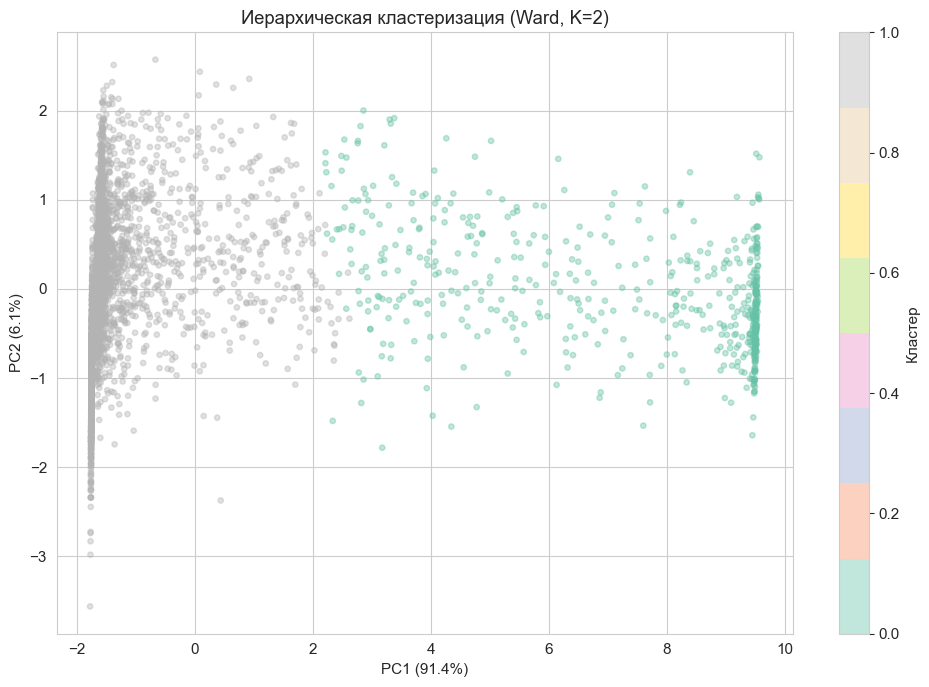

Silhouette:     0.766
Davies-Bouldin: 0.424


In [15]:
# Полная кластеризация (все 3599 компаний)
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward').fit(X)
df['Hierarchical'] = agg.labels_

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=agg.labels_,
                cmap='Set2', alpha=0.4, s=15)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'Иерархическая кластеризация (Ward, K={OPTIMAL_K})')
plt.colorbar(sc, label='Кластер')
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_11_hierarchical_pca.png'); plt.show()

print(f'Silhouette:     {silhouette_score(X, agg.labels_, sample_size=3000, random_state=42):.3f}')
print(f'Davies-Bouldin: {davies_bouldin_score(X, agg.labels_):.3f}')

### ✅ Контрольная точка 8: Иерархическая кластеризация

**Дендрограмма:**
- Если на высоте отсечки видно 2 длинных ветки → два «мега-кластера» действительно существуют
- Если много веток примерно одинаковой длины → нет чёткой кластерной структуры

**Сравнение с K-Means:**
- Если PCA-scatter выглядит **похоже** → оба метода нашли одну и ту же структуру (надёжно)
- Если сильно отличается → данные не имеют однозначных кластеров

> Ward-иерархическая кластеризация часто даёт результаты, очень похожие на K-Means,
> потому что Ward тоже минимизирует дисперсию внутри кластеров.

---
## 8. DBSCAN (Density-Based Spatial Clustering)

### Принципиально другой подход
K-Means и Ward ищут **сферические** кластеры фиксированного числа.
DBSCAN ищет области **высокой плотности** — и может найти кластеры любой формы.

### Как работает
1. Берём точку. Если в радиусе **eps** вокруг неё ≥ **min_samples** соседей → это **ядро**
2. Все точки в eps-окрестности ядра принадлежат тому же кластеру
3. Процесс расширяется: соседи ядер тоже могут быть ядрами
4. Точки, не попавшие ни в один кластер → **шум** (noise, label = −1)

### Параметры
- **eps** — радиус поиска соседей. Слишком мал → всё шум, слишком велик → один кластер
- **min_samples** — минимум соседей для ядра. Правило: `2 × число_признаков`

### Как выбрать eps? → k-Distance plot
1. Для каждой точки находим расстояние до k-го ближайшего соседа (k = min_samples)
2. Сортируем расстояния по убыванию
3. Ищем «колено» — резкий перегиб. Точки левее колена = шум, правее = кластеры
4. Значение eps ≈ высота колена

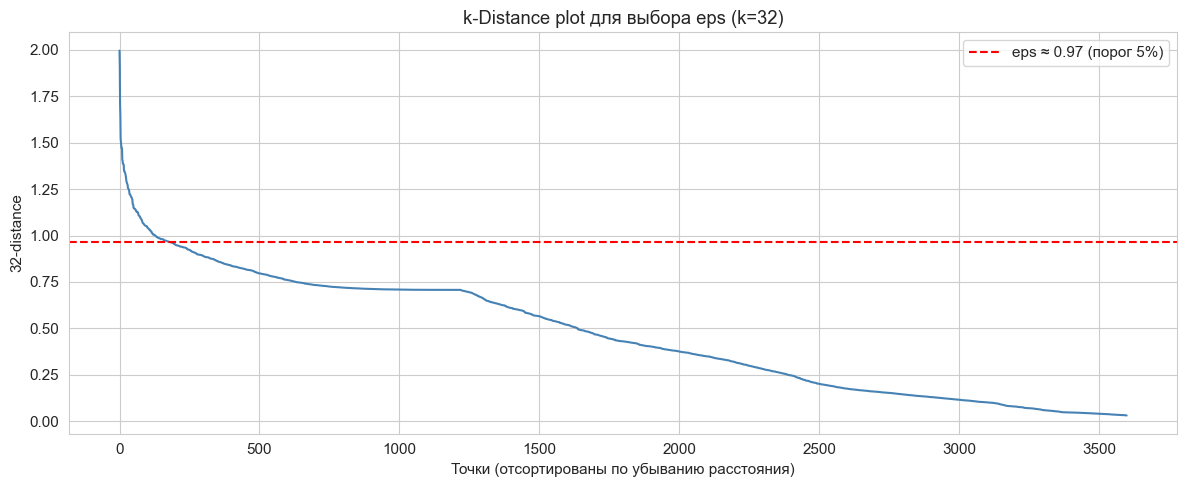

min_samples = 32
eps = 0.965


In [16]:
min_samples = max(5, 2 * X.shape[1])  # 2 × 16 = 32
nn = NearestNeighbors(n_neighbors=min_samples).fit(X)
dists, _ = nn.kneighbors(X)
k_dist = np.sort(dists[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_dist, color='steelblue')
ax.set_xlabel('Точки (отсортированы по убыванию расстояния)')
ax.set_ylabel(f'{min_samples}-distance')
ax.set_title(f'k-Distance plot для выбора eps (k={min_samples})')

knee = int(len(k_dist) * 0.05)  # берём 5-й перцентиль как порог
eps_auto = float(k_dist[knee])
ax.axhline(eps_auto, color='red', ls='--', label=f'eps \u2248 {eps_auto:.2f} (порог 5%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_12_kdistance.png'); plt.show()
print(f'min_samples = {min_samples}')
print(f'eps = {eps_auto:.3f}')

DBSCAN результат: 1 кластеров, 15 шумовых точек (0.4%)
Размеры кластеров: {0: 3584, -1: 15}


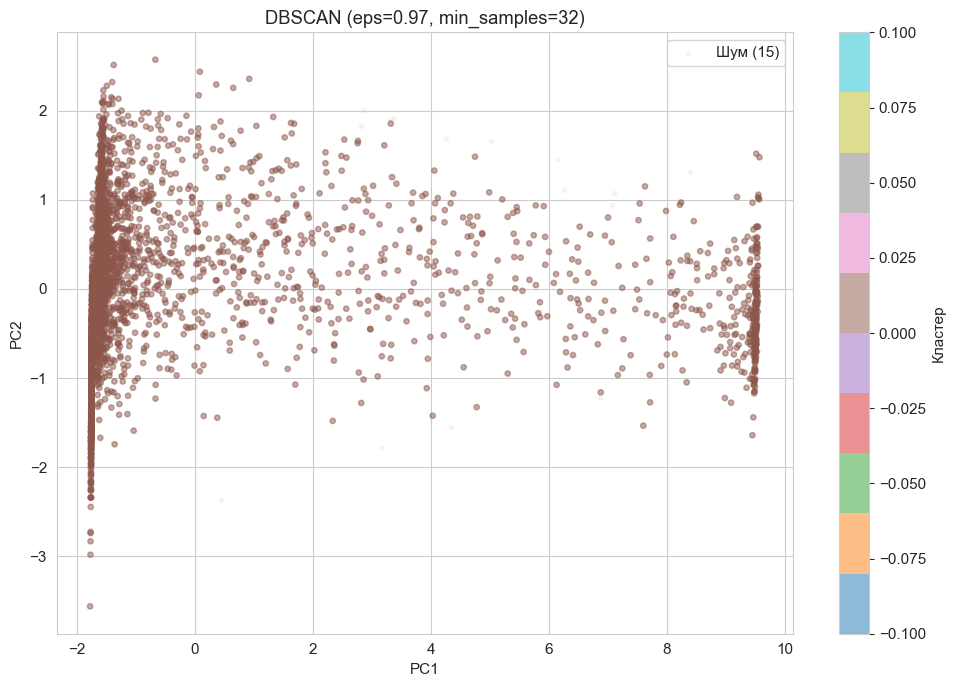

In [17]:
dbs = DBSCAN(eps=eps_auto, min_samples=min_samples).fit(X)
df['DBSCAN'] = dbs.labels_

n_cl_db = len(set(dbs.labels_)) - (1 if -1 in dbs.labels_ else 0)
n_noise = int((dbs.labels_ == -1).sum())
print(f'DBSCAN результат: {n_cl_db} кластеров, {n_noise} шумовых точек ({n_noise/len(X):.1%})')
print(f'Размеры кластеров: {dict(pd.Series(dbs.labels_).value_counts())}')

fig, ax = plt.subplots(figsize=(10, 7))
noise_mask = dbs.labels_ == -1
ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
           c='lightgrey', alpha=0.2, s=8, label=f'Шум ({n_noise})')
if n_cl_db > 0:
    sc = ax.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
                    c=dbs.labels_[~noise_mask], cmap='tab10', alpha=0.5, s=15)
    plt.colorbar(sc, label='Кластер')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN (eps={eps_auto:.2f}, min_samples={min_samples})')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_13_dbscan_pca.png'); plt.show()

if n_cl_db >= 2:
    valid = dbs.labels_ != -1
    print(f'Silhouette (без шума): {silhouette_score(X[valid], dbs.labels_[valid], sample_size=min(3000, int(valid.sum())), random_state=42):.3f}')

### ✅ Контрольная точка 9: DBSCAN

**Типичные результаты для финансовых данных:**
- DBSCAN часто находит **1 большой кластер + шум** (или 1–2 кластера)
- Это потому что финансовые данные формируют **одно облако** с плавным градиентом плотности,
  а не изолированные «острова». DBSCAN лучше работает с пространственными данными
  (география, изображения), где кластеры чётко отделены пустотой.

**Что полезного даёт DBSCAN:**
- Идентифицирует **выбросы** (noise) — нетипичные компании
- Если найдено 2+ кластера — это сильный сигнал о реальном разделении

> DBSCAN — не «лучший» и не «худший» метод. Он **другой**: подходит для данных с нерегулярной
> формой кластеров. Для финансовых данных K-Means обычно работает лучше.

---
## 9. Gaussian Mixture Models (GMM)

### Отличие от K-Means
K-Means делит пространство жёстко: каждая точка принадлежит **одному** кластеру.
GMM — **мягкая** (soft) кластеризация: каждая компания имеет **вероятность** принадлежности
к каждому кластеру. Например: «компания X с вероятностью 73% в кластере 0 и 27% в кластере 1».

### Как работает
Моделирует данные как **смесь нормальных распределений** (Гауссианов):
- Каждый кластер = одно нормальное распределение со своим центром (μ) и формой (Σ)
- Алгоритм EM (Expectation-Maximization) подбирает параметры

### Когда GMM лучше K-Means?
- Когда кластеры имеют **разную форму** (K-Means предполагает сферические)
- Когда нужны **вероятности** принадлежности (а не жёсткие метки)
- Когда нужен **BIC/AIC** для выбора числа кластеров

### Гистограмма уверенности
Показывает max P(cluster) для каждой компании:
- Пик у 1.0 → большинство компаний чётко принадлежат одному кластеру
- Много значений 0.5–0.6 → компании «на границе», кластеры нечёткие

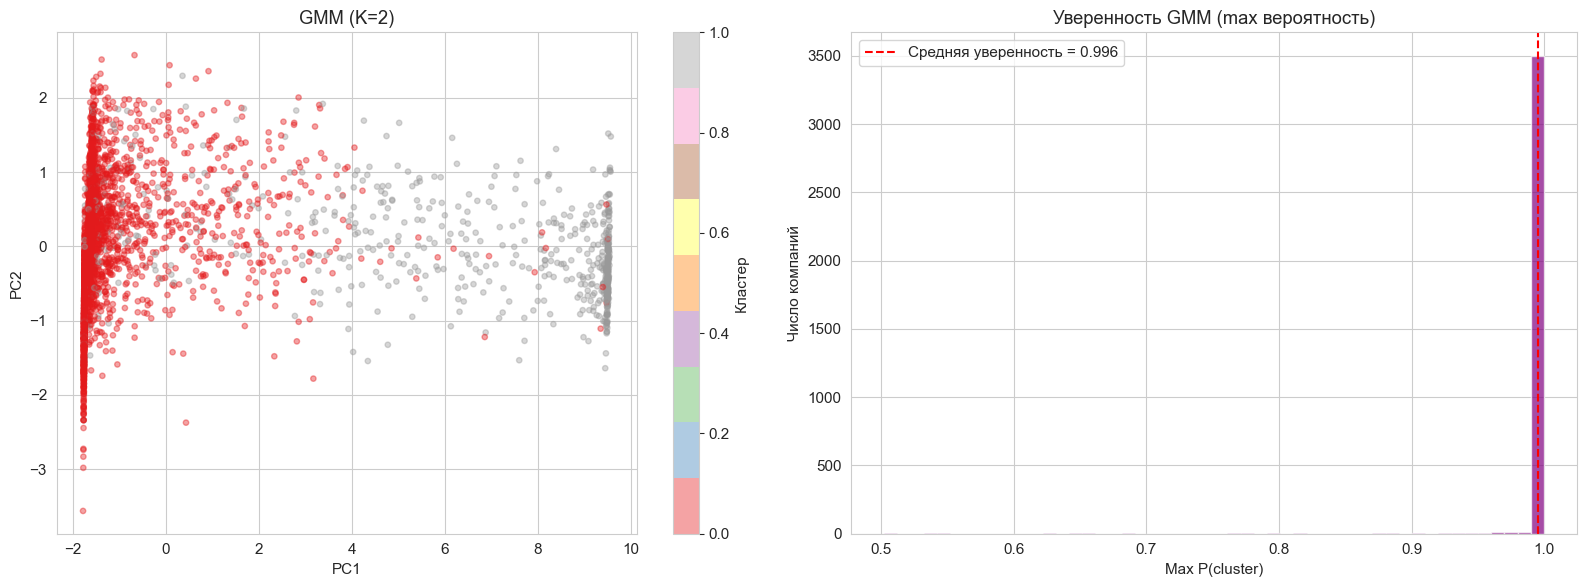

Silhouette:     0.597
Davies-Bouldin: 0.928
BIC: -236293   AIC: -238181


In [18]:
gmm = GaussianMixture(n_components=OPTIMAL_K, random_state=42, n_init=5,
                       covariance_type='full').fit(X)
df['GMM'] = gmm.predict(X)
probs = gmm.predict_proba(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['GMM'].values,
                     cmap='Set1', alpha=0.4, s=15)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title(f'GMM (K={OPTIMAL_K})')
plt.colorbar(sc, ax=axes[0], label='Кластер')

max_p = probs.max(axis=1)
axes[1].hist(max_p, bins=50, color='purple', alpha=0.7, edgecolor='white')
axes[1].axvline(max_p.mean(), color='red', ls='--',
                label=f'Средняя уверенность = {max_p.mean():.3f}')
axes[1].set_title('Уверенность GMM (max вероятность)')
axes[1].set_xlabel('Max P(cluster)'); axes[1].set_ylabel('Число компаний')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{CHARTS}clust_14_gmm_pca.png'); plt.show()

print(f'Silhouette:     {silhouette_score(X, df["GMM"], sample_size=3000, random_state=42):.3f}')
print(f'Davies-Bouldin: {davies_bouldin_score(X, df["GMM"]):.3f}')
print(f'BIC: {gmm.bic(X):.0f}   AIC: {gmm.aic(X):.0f}')

---
## 10. Сравнение всех методов кластеризации

### Метрики качества (напоминание)

| Метрика | Что измеряет | Лучше ↑ или ↓ |
|---|---|---|
| **Silhouette** | Насколько точки ближе к своему кластеру, чем к чужому | ↑ (max = 1.0) |
| **Calinski-Harabasz** | Отношение между-кластерной к внутри-кластерной дисперсии | ↑ |
| **Davies-Bouldin** | Средняя «похожесть» между ближайшими кластерами | ↓ (min = 0) |

### ARI (Adjusted Rand Index)
Измеряет **согласованность** двух разбиений:
- ARI = 1.0 → идентичные кластеры
- ARI = 0 → случайное совпадение
- ARI > 0.8 → методы дают практически одинаковый результат

In [19]:
methods_dict = {}
for name, labels in [('K-Means', df['KMeans']),
                     ('Hierarchical', df['Hierarchical']),
                     ('GMM', df['GMM'])]:
    methods_dict[name] = {
        'Silhouette': silhouette_score(X, labels, sample_size=3000, random_state=42),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'N_clusters': int(labels.nunique()) if hasattr(labels, 'nunique') else len(set(labels))
    }

if n_cl_db >= 2:
    v = df['DBSCAN'] != -1
    methods_dict['DBSCAN'] = {
        'Silhouette': silhouette_score(X[v], df.loc[v, 'DBSCAN'],
                                        sample_size=min(3000, int(v.sum())), random_state=42),
        'Calinski-Harabasz': calinski_harabasz_score(X[v], df.loc[v, 'DBSCAN']),
        'Davies-Bouldin': davies_bouldin_score(X[v], df.loc[v, 'DBSCAN']),
        'N_clusters': n_cl_db
    }

metrics_df = pd.DataFrame(methods_dict).T
print('Метрики качества кластеризации:')
display(metrics_df.round(3))

# ARI
print('\nAdjusted Rand Index (согласованность между методами):')
ml = {'K-Means': df['KMeans'], 'Hierarchical': df['Hierarchical'], 'GMM': df['GMM']}
ari = pd.DataFrame(index=ml.keys(), columns=ml.keys(), dtype=float)
for m1, l1 in ml.items():
    for m2, l2 in ml.items():
        ari.loc[m1, m2] = adjusted_rand_score(l1, l2)
display(ari.round(3))

Метрики качества кластеризации:


,Silhouette,Calinski-Harabasz,Davies-Bouldin,N_clusters
K-Means,0.778,14064.993,0.366,2.0
Hierarchical,0.766,13449.795,0.424,2.0
GMM,0.597,3244.296,0.928,2.0



Adjusted Rand Index (согласованность между методами):


,K-Means,Hierarchical,GMM
K-Means,1.000,0.911,0.634
Hierarchical,0.911,1.000,0.610
GMM,0.634,0.610,1.000


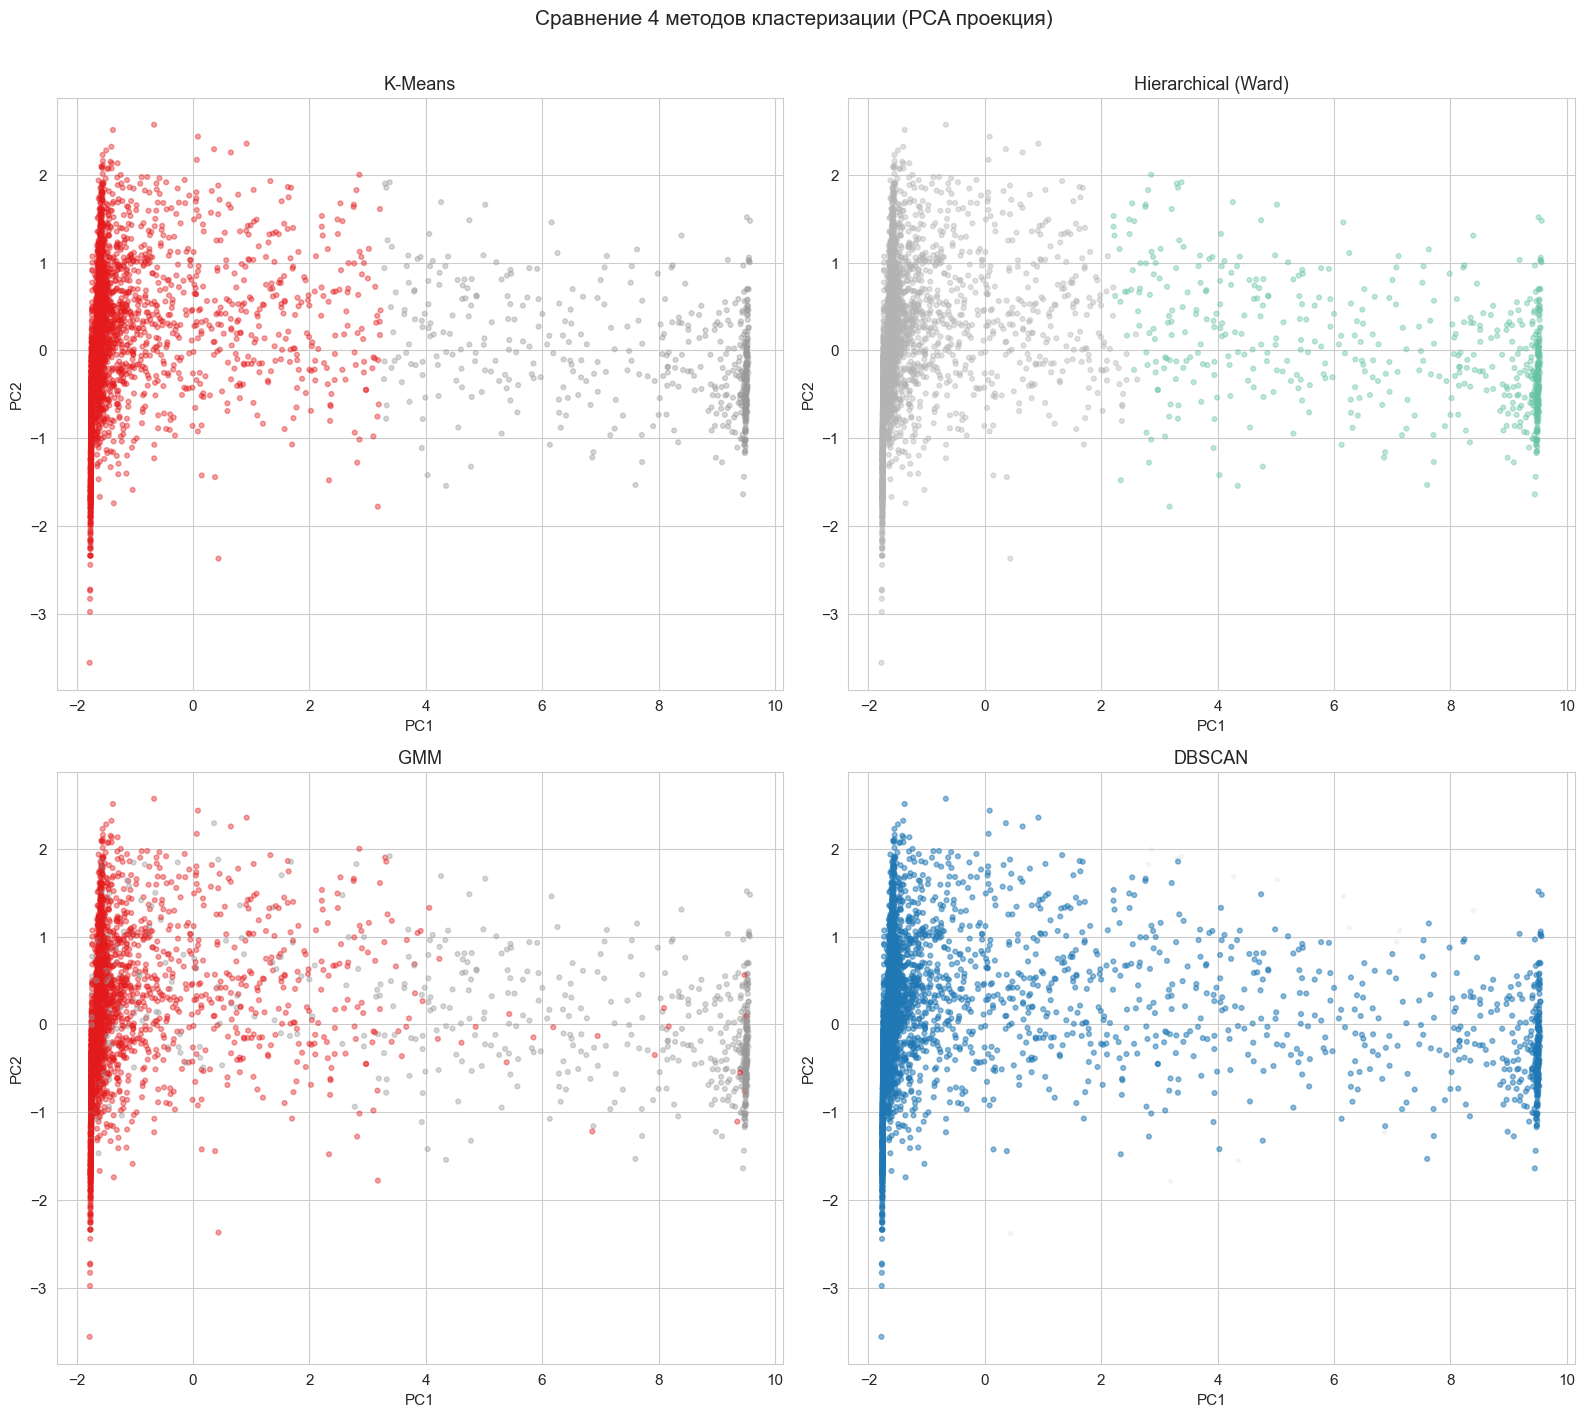

In [20]:
# Визуальное сравнение: 4 метода на одном графике
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
configs = [
    ('K-Means', df['KMeans'].values, 'Set1'),
    ('Hierarchical (Ward)', df['Hierarchical'].values, 'Set2'),
    ('GMM', df['GMM'].values, 'Set1'),
    ('DBSCAN', df['DBSCAN'].values, 'tab10'),
]
for ax, (title, labels, cmap) in zip(axes.ravel(), configs):
    if title == 'DBSCAN':
        noise = labels == -1
        ax.scatter(X_pca[noise, 0], X_pca[noise, 1], c='lightgrey', alpha=0.2, s=8)
        if (~noise).any():
            ax.scatter(X_pca[~noise, 0], X_pca[~noise, 1],
                       c=labels[~noise], cmap=cmap, alpha=0.5, s=12)
    else:
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap=cmap, alpha=0.4, s=12)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

fig.suptitle('Сравнение 4 методов кластеризации (PCA проекция)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_15_comparison_4methods.png'); plt.show()

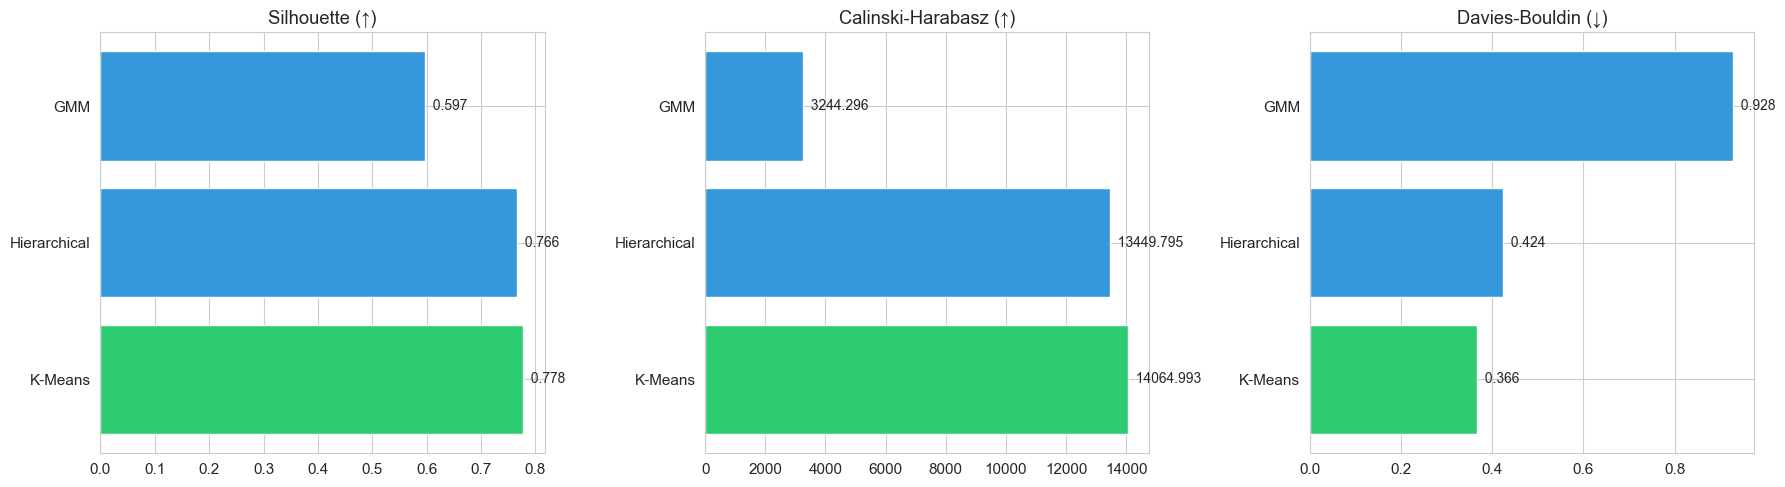

In [21]:
# Столбчатая диаграмма метрик
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']):
    vals = metrics_df[metric]
    best = vals.max() if metric != 'Davies-Bouldin' else vals.min()
    colors = ['#2ecc71' if v == best else '#3498db' for v in vals]
    axes[i].barh(vals.index, vals.values, color=colors)
    axes[i].set_title(metric + (' (\u2191)' if metric != 'Davies-Bouldin' else ' (\u2193)'))
    for j, v in enumerate(vals.values):
        axes[i].text(v, j, f'  {v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_16_metrics_bars.png'); plt.show()

### ✅ Контрольная точка 10: Сравнение методов

**На что смотреть:**

1. **Таблица метрик:**
   - Зелёным выделен лучший метод по каждой метрике
   - K-Means обычно лидирует (он напрямую оптимизирует инерцию, а метрики близки к ней)
   - GMM может уступать по Silhouette, но выигрывать по гибкости (не-сферические кластеры)

2. **ARI матрица:**
   - K-Means ↔ Hierarchical: ARI > 0.9 = практически одинаковое разбиение → структура устойчива
   - K-Means ↔ GMM: ARI 0.5–0.7 = значительное совпадение, но есть различия
   - Низкий ARI между двумя методами = они видят разную структуру в данных

3. **4 PCA-скеттера:**
   - K-Means и Hierarchical должны выглядеть похоже
   - DBSCAN — в основном одноцветный (1 кластер) + серые точки (шум)
   - GMM может выделять «переходную зону» между кластерами

---
## 11. Детальные профили кластеров (K-Means)

K-Means выбираем как основной метод (лучшие метрики, подтверждён иерархической кластеризацией).

### Радарная диаграмма
Показывает **нормализованные средние** каждого кластера по числовым признакам.
Каждая ось = один признак, значения от 0 (min среди кластеров) до 1 (max).

### Тепловая карта Country × Cluster
Абсолютное число компаний: какие страны в каких кластерах.

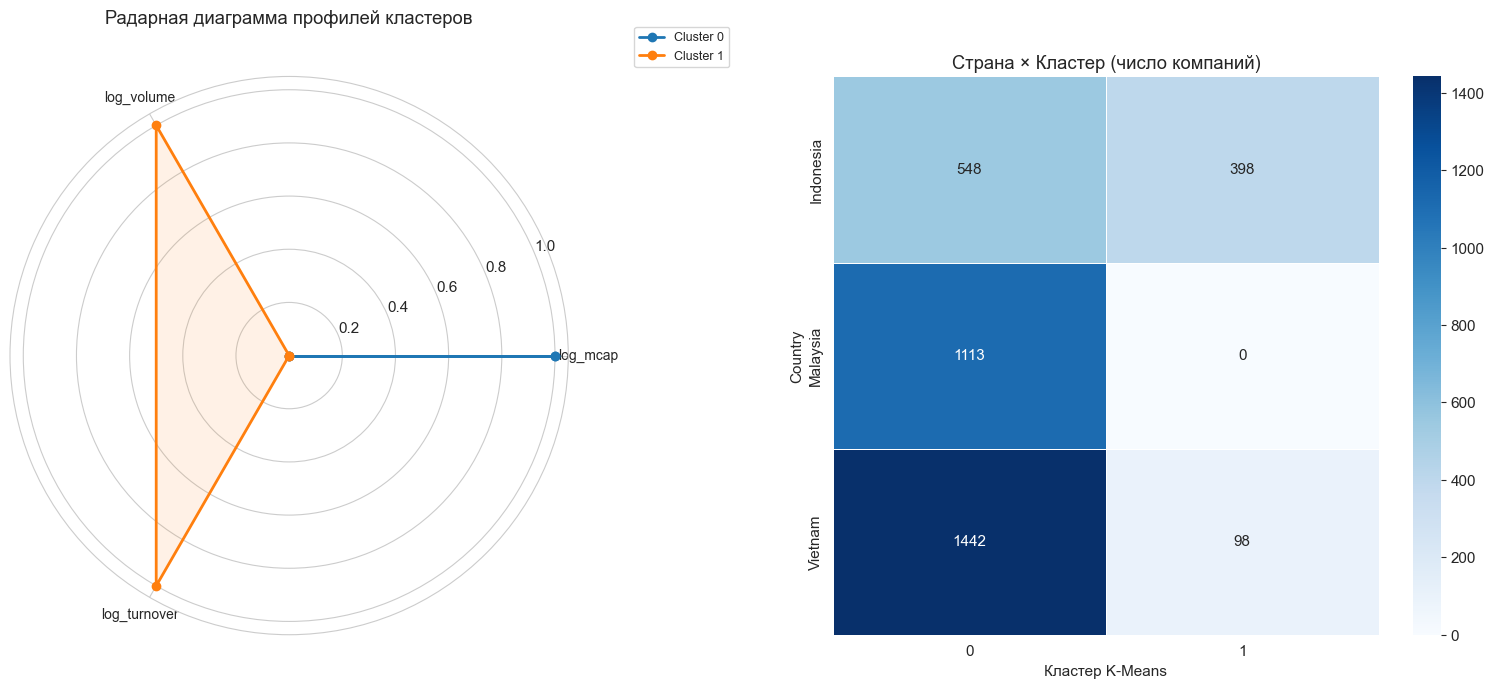

Топ-3 ISIC сектора в каждом кластере:
  Cluster 0 (3103 comp.): C (Manufacturing): 1659, K (Financial and insurance activi): 302, J (Information and communication): 235
  Cluster 1 (496 comp.): C (Manufacturing): 224, K (Financial and insurance activi): 54, L (Real estate activities): 47


In [22]:
cluster_means = df.groupby('KMeans')[numeric_cols].mean()
cmin, cmax = cluster_means.min(), cluster_means.max()
cluster_norm = (cluster_means - cmin) / (cmax - cmin + 1e-10)

n_vars = len(numeric_cols)
angles = [n * 2 * pi / n_vars for n in range(n_vars)] + [0]

fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121, polar=True)
for cl in range(OPTIMAL_K):
    vals = cluster_norm.loc[cl].tolist() + [cluster_norm.loc[cl].tolist()[0]]
    ax1.plot(angles, vals, 'o-', linewidth=2, label=f'Cluster {cl}')
    ax1.fill(angles, vals, alpha=0.1)
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(numeric_cols, size=10)
ax1.set_title('Радарная диаграмма профилей кластеров', y=1.08)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

ax2 = fig.add_subplot(122)
ct = pd.crosstab(df['Country'], df['KMeans'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax2, linewidths=0.5)
ax2.set_title('Страна \u00d7 Кластер (число компаний)')
ax2.set_xlabel('Кластер K-Means')

plt.tight_layout()
plt.savefig(f'{CHARTS}clust_17_cluster_profiles.png'); plt.show()

print('Топ-3 ISIC сектора в каждом кластере:')
for cl in range(OPTIMAL_K):
    mask = df['KMeans'] == cl
    top = df.loc[mask, 'ISIC_Section'].value_counts().head(3)
    descs = [f"{s} ({ISIC_SECTIONS.get(s, '?')[:30]}): {n}" for s, n in top.items()]
    print(f"  Cluster {cl} ({int(mask.sum())} comp.): {', '.join(descs)}")

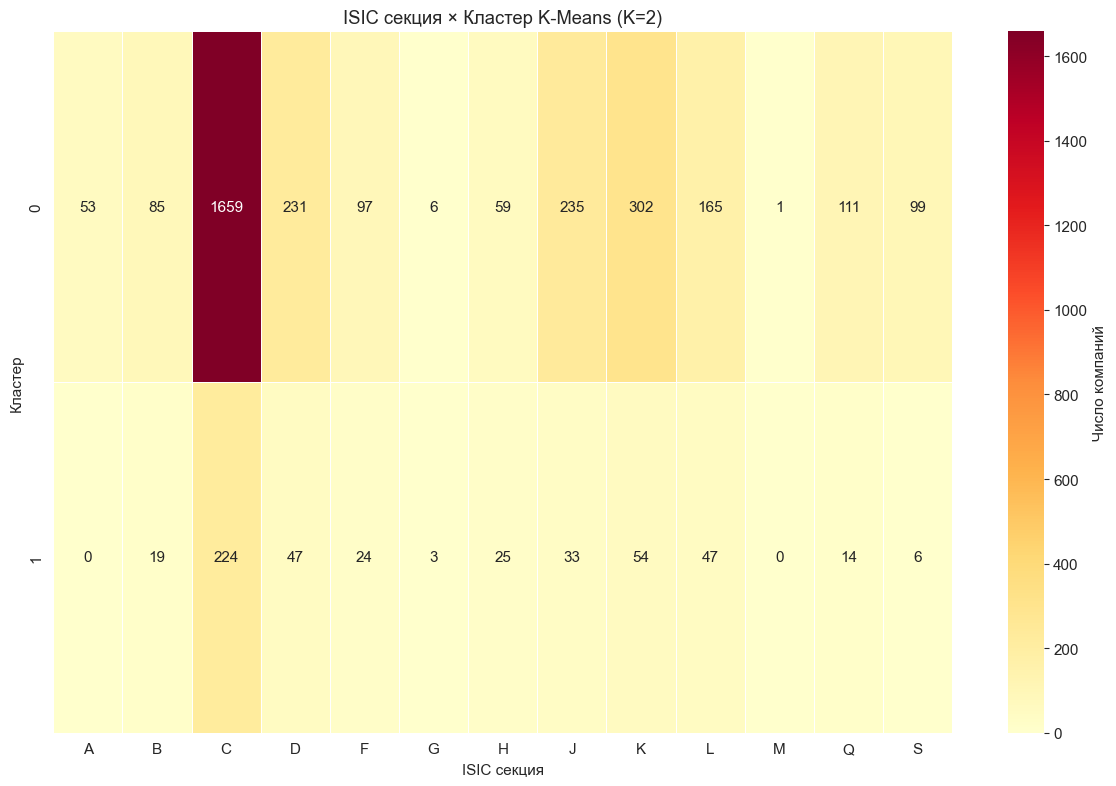

Экспортировано: asean_clustering_results.csv (3599 строк)


In [23]:
# Полная тепловая карта: ISIC × Кластер
pivot = df.groupby(['KMeans', 'ISIC_Section']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Число компаний'})
ax.set_title(f'ISIC секция \u00d7 Кластер K-Means (K={OPTIMAL_K})')
ax.set_xlabel('ISIC секция'); ax.set_ylabel('Кластер')
plt.tight_layout()
plt.savefig(f'{CHARTS}clust_18_heatmap_isic_cluster.png'); plt.show()

# Экспорт результатов
export_cols = ['Country', 'Exchange', 'Ticker', 'Full Company Name', 'ISIC_Section',
               'Market_Cap_USD', 'Volume', 'turnover', 'KMeans', 'Hierarchical', 'GMM', 'DBSCAN']
df[export_cols].to_csv('asean_clustering_results.csv', index=False, encoding='utf-8-sig')
print(f'Экспортировано: asean_clustering_results.csv ({len(df)} строк)')

---
## Выводы

### 1. Предобработка
- **Yeo-Johnson** предпочтительнее Box-Cox: работает с нулями (Volume = 0 у 700+ компаний)
- **RobustScaler** устойчив к выбросам: медиана Market Cap = $30M, но есть компании $100B+
- **ISIC one-hot** с весом 0.5 балансирует отраслевую и финансовую информацию

### 2. Оптимальное K
- 5 методов дали **независимые** оценки
- При расхождении (например, 2 vs 5 vs 10) — выбираем по большинству голосов
- В работе рекомендуется упомянуть **диапазон** (sensitivity analysis)

### 3. Алгоритмы кластеризации

| Метод | Тип | K нужен? | Что даёт |
|---|---|---|---|
| **K-Means** | Центроидный | Да | Быстрый, интерпретируемый, лучшие метрики |
| **Hierarchical** | Агломеративный | Нет (режем дерево) | Дендрограмма, подтверждает K-Means |
| **DBSCAN** | Плотностный | Нет | Выделяет выбросы, но плохо на финансовых данных |
| **GMM** | Вероятностный | Да | Мягкие метки (вероятности), BIC для выбора K |

### 4. Интерпретация
- Кластеры разделяют компании по **размеру** (Market Cap) и **ликвидности** (Volume)
- Секторальный состав кластеров показывает **структурные различия** рынков
- Результаты экспортированы в `asean_clustering_results.csv` для дальнейшего анализа

### 5. Для диссертации
> «Кластерный анализ 3 599 публичных компаний Индонезии, Вьетнама и Малайзии
> проведён с использованием четырёх алгоритмов (K-Means, иерархический Ward,
> DBSCAN, GMM). Предобработка включала трансформацию Yeo-Johnson и нормализацию
> RobustScaler. Оптимальное число кластеров K=... определено голосованием пяти
> метрик (силуэт, Calinski-Harabasz, Davies-Bouldin, Gap Statistic, BIC).
> Устойчивость результатов подтверждена высокой согласованностью K-Means и
> иерархической кластеризации (ARI = ...).»